## ⚙️ Libraries Import


In [1]:
!pip install --upgrade tensorflow tensorboard
!pip install --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: p

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import scipy.sparse as sps
import copy
import shutil
from datetime import datetime
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import random
import torch
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from typing import List, Dict
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## ⏳ Data Loading


In [3]:
dataset = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv')
userID = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv')
validationset = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv')

dataset.drop('n_legs', axis=1, inplace=True)
dataset.drop('n_hands', axis=1, inplace=True)
dataset.drop('n_eyes', axis=1, inplace=True)
dataset.drop('pain_survey_1', axis=1, inplace=True)
dataset.drop('pain_survey_2', axis=1, inplace=True)
dataset.drop('pain_survey_3', axis=1, inplace=True)
dataset.drop('pain_survey_4', axis=1, inplace=True)
dataset.drop("joint_30", axis=1, inplace=True)

validationset.drop('n_legs', axis=1, inplace=True)
validationset.drop('n_hands', axis=1, inplace=True)
validationset.drop('n_eyes', axis=1, inplace=True)
validationset.drop('pain_survey_1', axis=1, inplace=True)
validationset.drop('pain_survey_2', axis=1, inplace=True)
validationset.drop('pain_survey_3', axis=1, inplace=True)
validationset.drop('pain_survey_4', axis=1, inplace=True)
validationset.drop("joint_30", axis=1, inplace=True)

## Data visualization and preprocessing

First of all are visualized all the joints features

--- CONTINUOUS FEATURE EXPLORATORY DATA ANALYSIS (EDA) ---

Analyzing 31 Continuous Features: ['time', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']


==================== FEATURE: time ====================
- Unique Values       : 160.0000
- Non-Null Count      : 211840.0000
- Mean                : 79.5000
- Variance            : 2133.2601
- Standard Deviation  : 46.1872
- Min Value           : 0.0000
- Max Value           : 159.0000
- Skewness            : 0.0000

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (2133.26) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


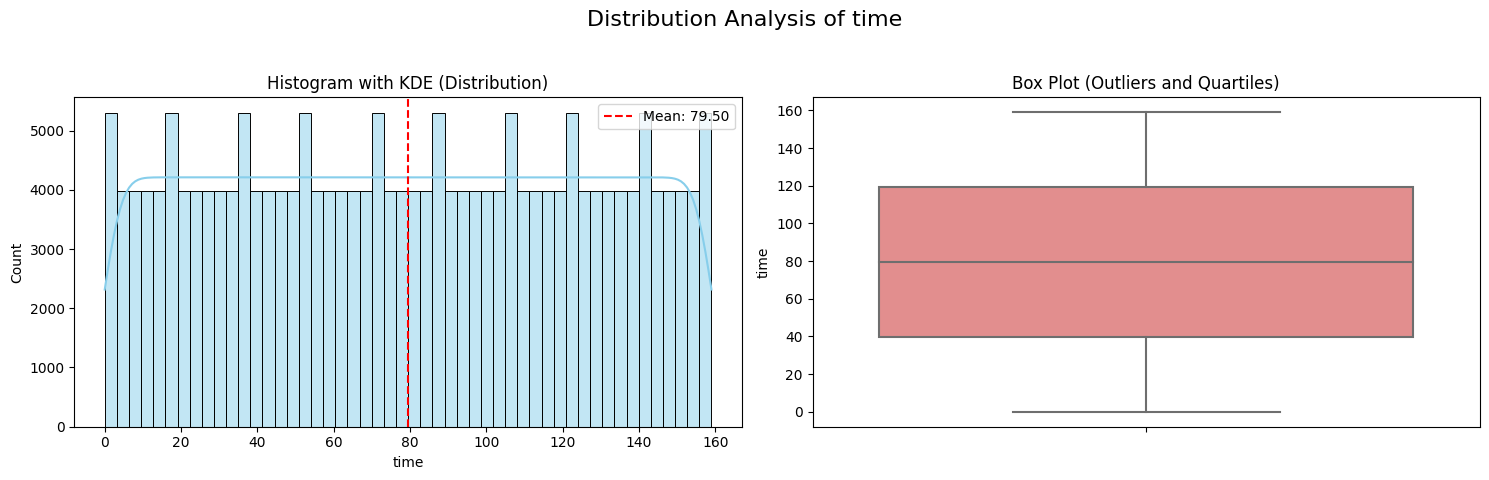


==================== FEATURE: joint_00 ====================
- Unique Values       : 211808.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9841
- Variance            : 0.0419
- Standard Deviation  : 0.2047
- Min Value           : 0.0000
- Max Value           : 1.5003
- Skewness            : -1.0299

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.03. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


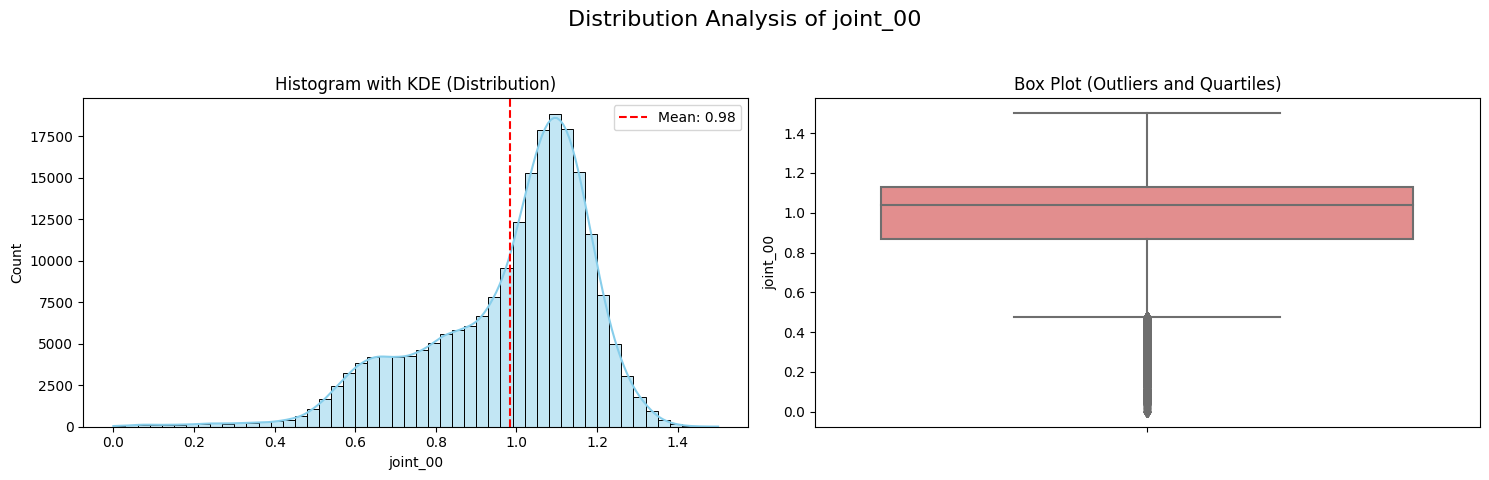


==================== FEATURE: joint_01 ====================
- Unique Values       : 211822.0000
- Non-Null Count      : 211840.0000
- Mean                : 1.0023
- Variance            : 0.0365
- Standard Deviation  : 0.1912
- Min Value           : 0.0368
- Max Value           : 1.4990
- Skewness            : -1.1677

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.17. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


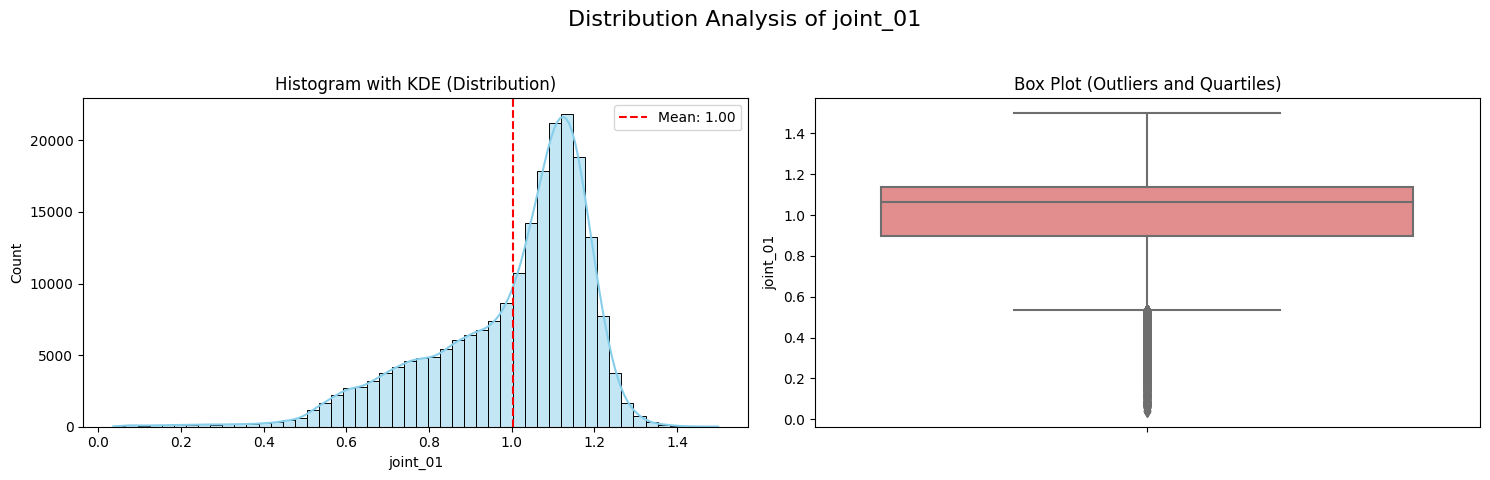


==================== FEATURE: joint_02 ====================
- Unique Values       : 211365.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8337
- Variance            : 0.0891
- Standard Deviation  : 0.2985
- Min Value           : 0.0148
- Max Value           : 1.3470
- Skewness            : -0.9906

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.09) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


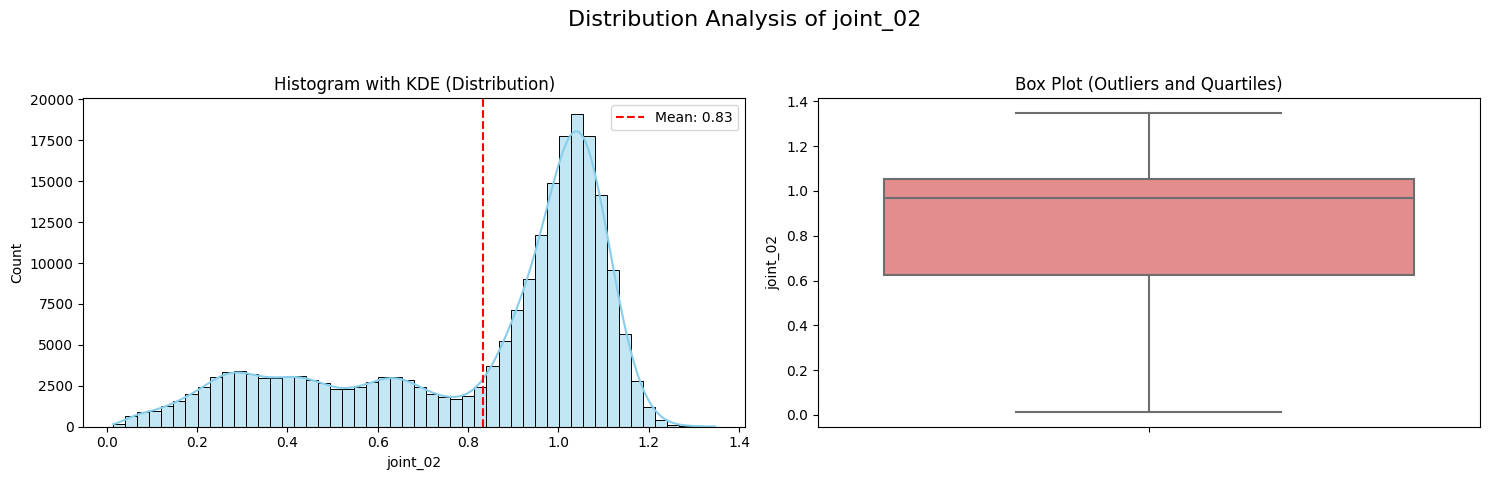


==================== FEATURE: joint_03 ====================
- Unique Values       : 211835.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8400
- Variance            : 0.0891
- Standard Deviation  : 0.2986
- Min Value           : 0.0476
- Max Value           : 1.3339
- Skewness            : -0.9322

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.09) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


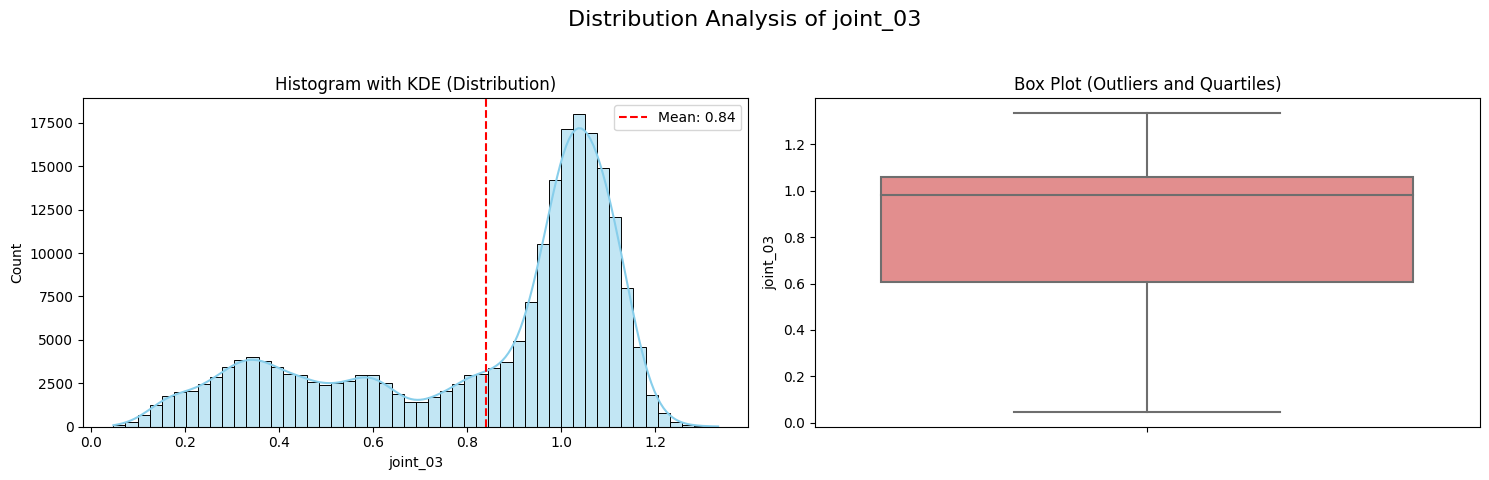


==================== FEATURE: joint_04 ====================
- Unique Values       : 204464.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7275
- Variance            : 0.1732
- Standard Deviation  : 0.4161
- Min Value           : 0.0000
- Max Value           : 1.4206
- Skewness            : -0.6584

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.17) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


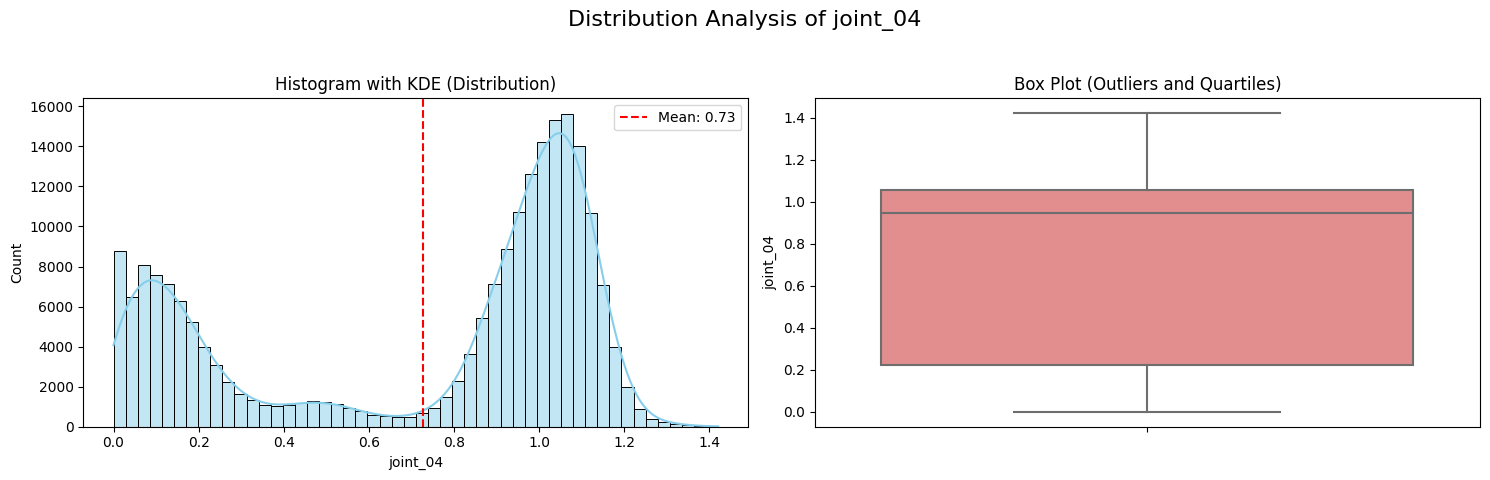


==================== FEATURE: joint_05 ====================
- Unique Values       : 209734.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7702
- Variance            : 0.1624
- Standard Deviation  : 0.4030
- Min Value           : 0.0013
- Max Value           : 1.4210
- Skewness            : -0.6827

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.16) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


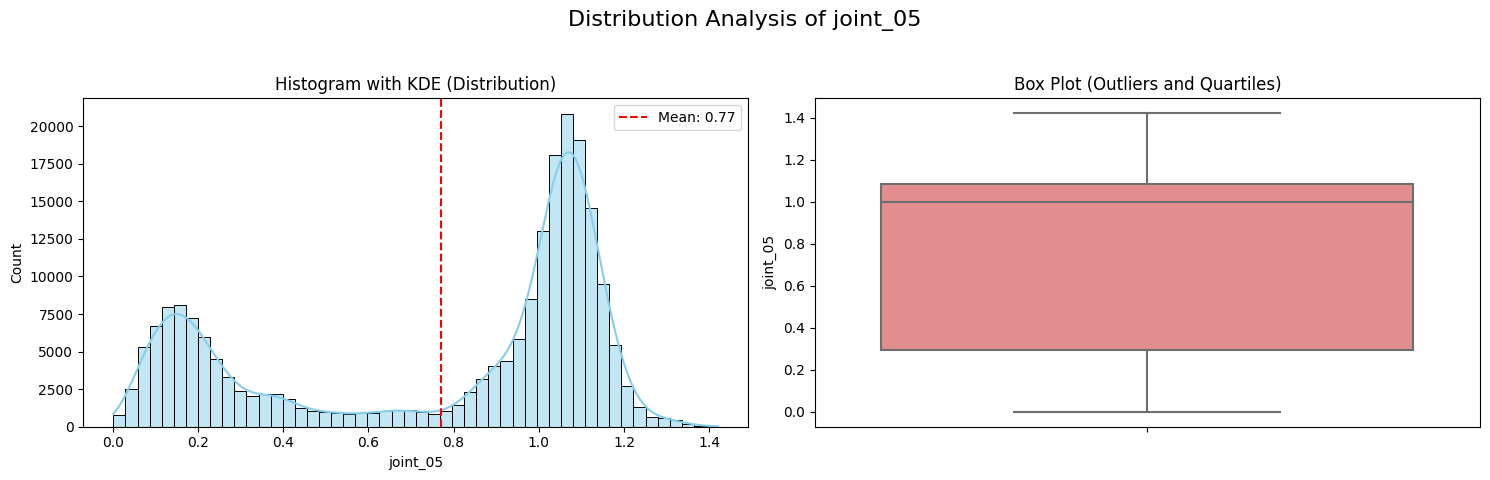


==================== FEATURE: joint_06 ====================
- Unique Values       : 209992.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8910
- Variance            : 0.0552
- Standard Deviation  : 0.2349
- Min Value           : 0.0000
- Max Value           : 1.4472
- Skewness            : -1.8095

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.81. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


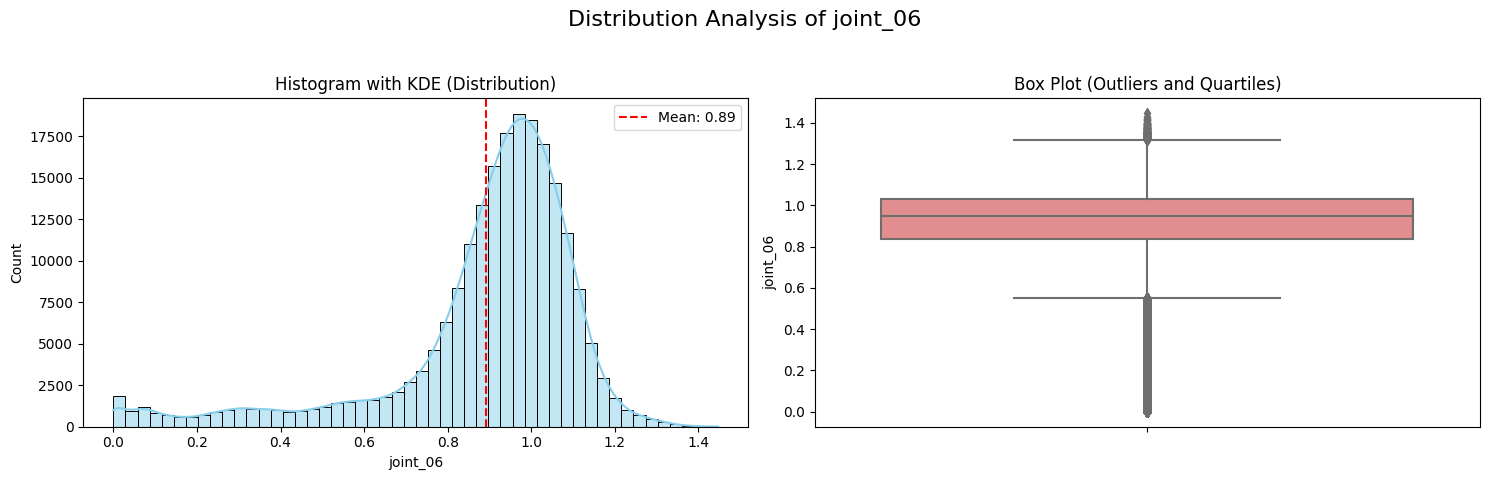


==================== FEATURE: joint_07 ====================
- Unique Values       : 211498.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8889
- Variance            : 0.0553
- Standard Deviation  : 0.2351
- Min Value           : 0.0000
- Max Value           : 1.4522
- Skewness            : -1.6285

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.63. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


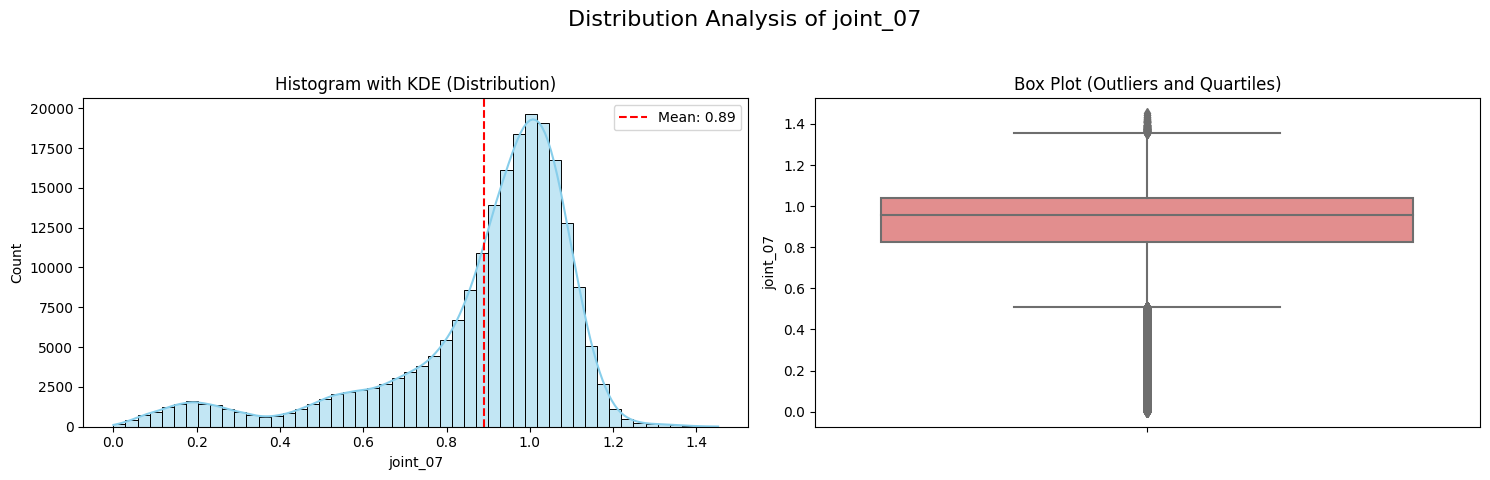


==================== FEATURE: joint_08 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9045
- Variance            : 0.0363
- Standard Deviation  : 0.1904
- Min Value           : 0.0329
- Max Value           : 1.4210
- Skewness            : -0.2195

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.04) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


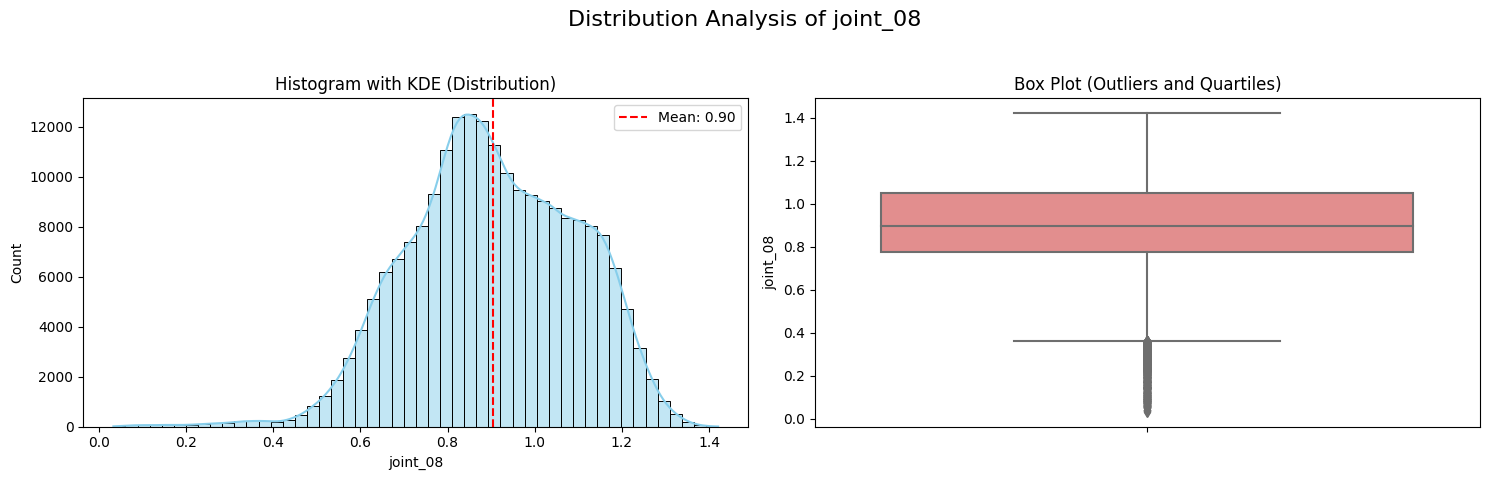


==================== FEATURE: joint_09 ====================
- Unique Values       : 211786.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9393
- Variance            : 0.0322
- Standard Deviation  : 0.1796
- Min Value           : 0.0000
- Max Value           : 1.4294
- Skewness            : -1.0555

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.06. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


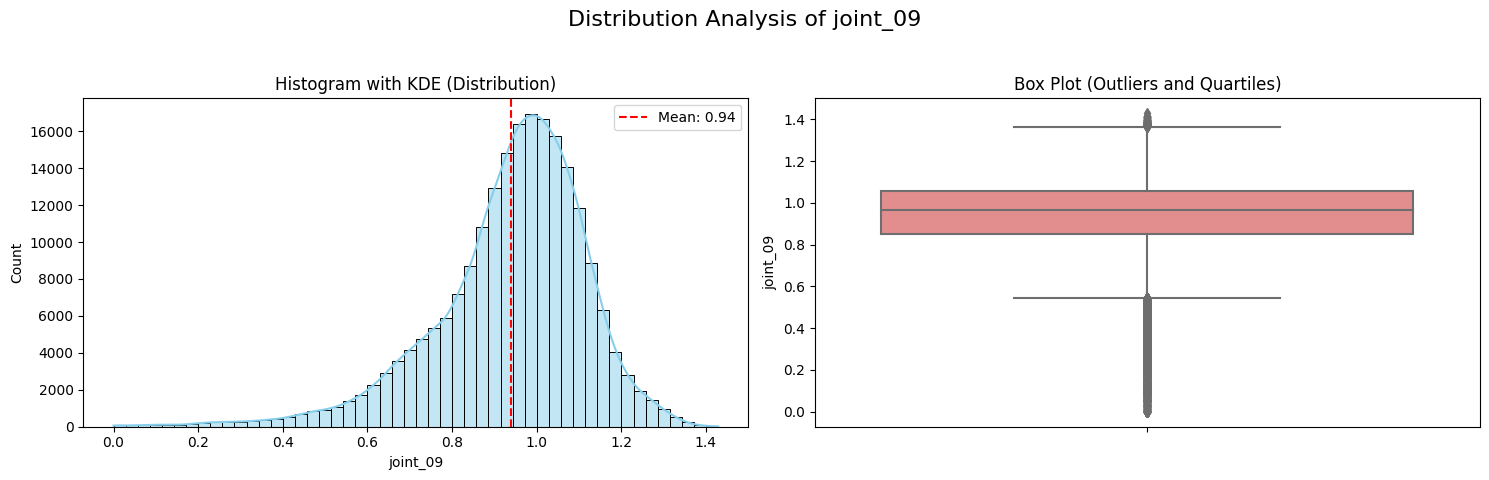


==================== FEATURE: joint_10 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7513
- Variance            : 0.0625
- Standard Deviation  : 0.2500
- Min Value           : 0.1957
- Max Value           : 1.5126
- Skewness            : 0.2932

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.06) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


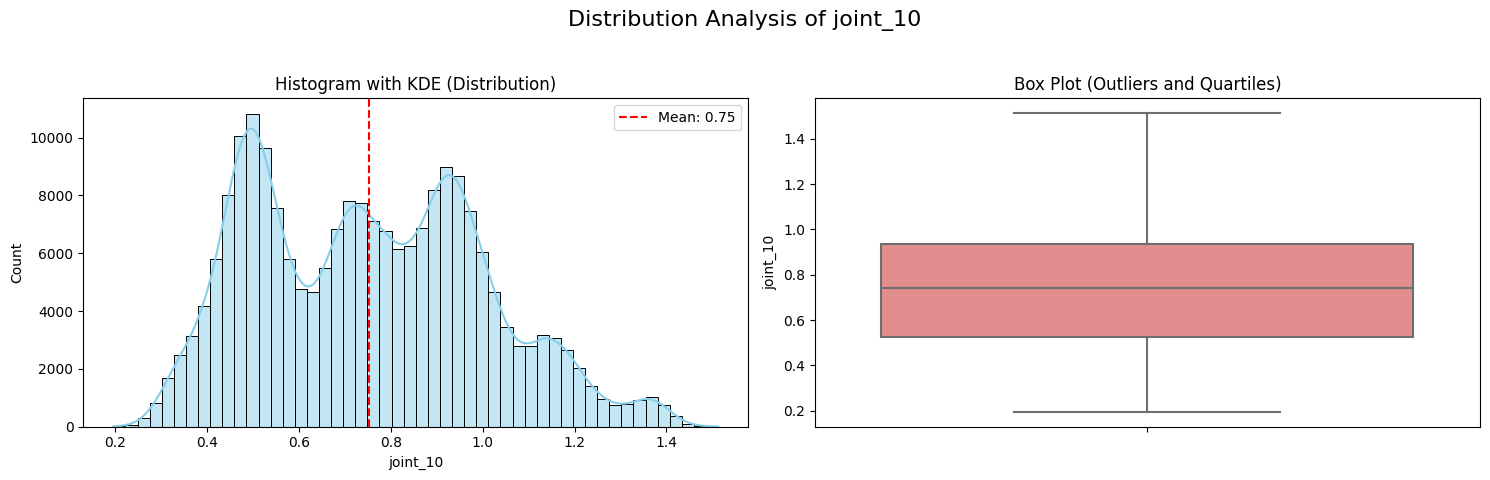


==================== FEATURE: joint_11 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7243
- Variance            : 0.0610
- Standard Deviation  : 0.2469
- Min Value           : 0.0391
- Max Value           : 1.5010
- Skewness            : 0.1870

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.06) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


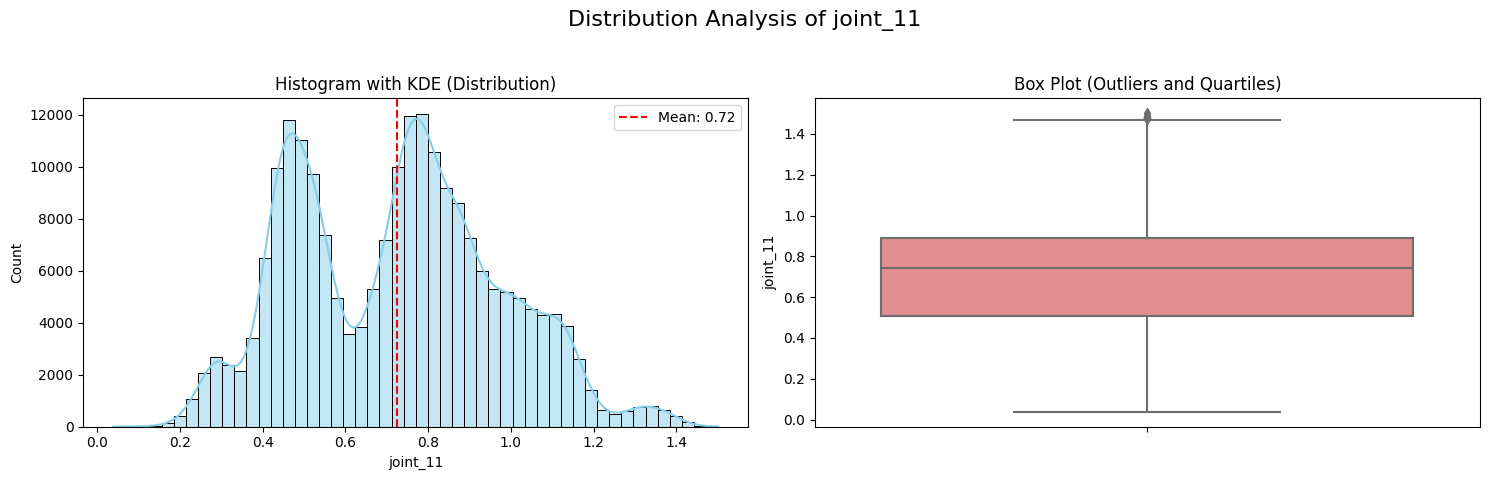


==================== FEATURE: joint_12 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 1.1203
- Variance            : 0.0138
- Standard Deviation  : 0.1176
- Min Value           : 0.2327
- Max Value           : 1.5003
- Skewness            : -1.2129

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.21. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


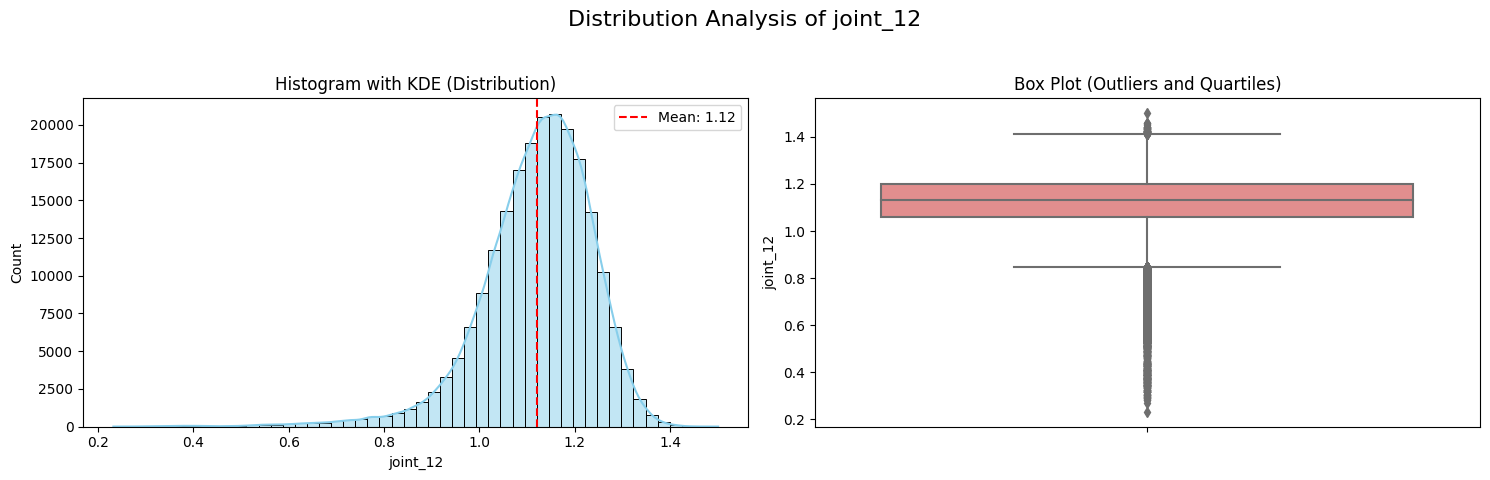


==================== FEATURE: joint_13 ====================
- Unique Values       : 132229.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0013
- Min Value           : 0.0000
- Max Value           : 0.1701
- Skewness            : 55.4775

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 55.48. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


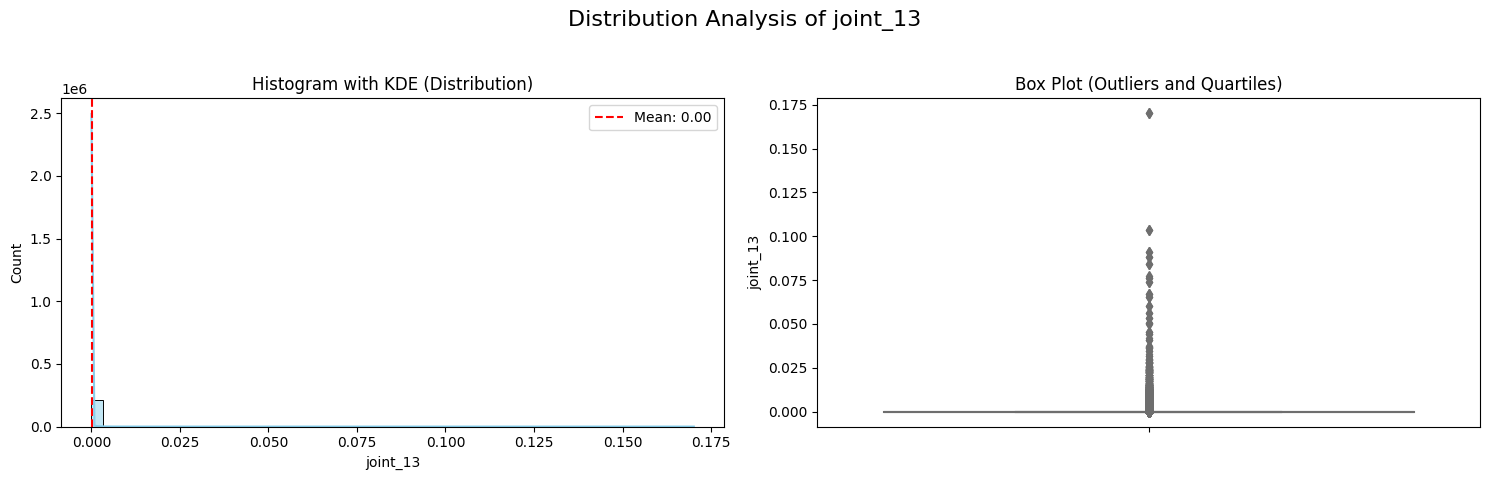


==================== FEATURE: joint_14 ====================
- Unique Values       : 133445.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0011
- Min Value           : 0.0000
- Max Value           : 0.1255
- Skewness            : 52.5850

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 52.58. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


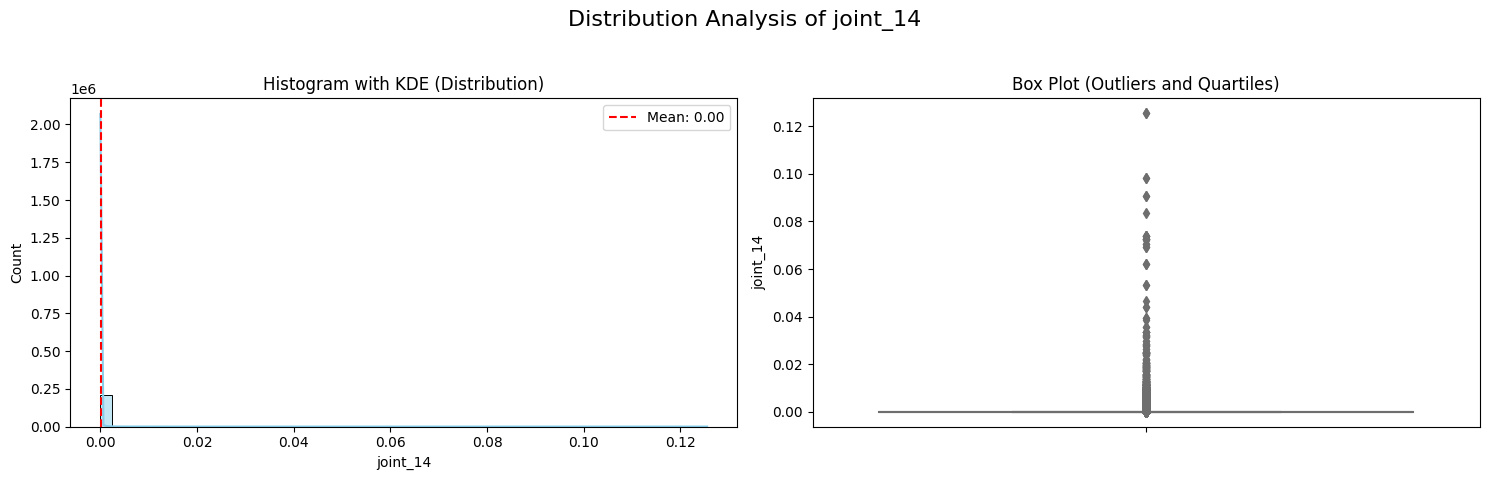


==================== FEATURE: joint_15 ====================
- Unique Values       : 126381.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0018
- Min Value           : 0.0000
- Max Value           : 0.3148
- Skewness            : 71.5486

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 71.55. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


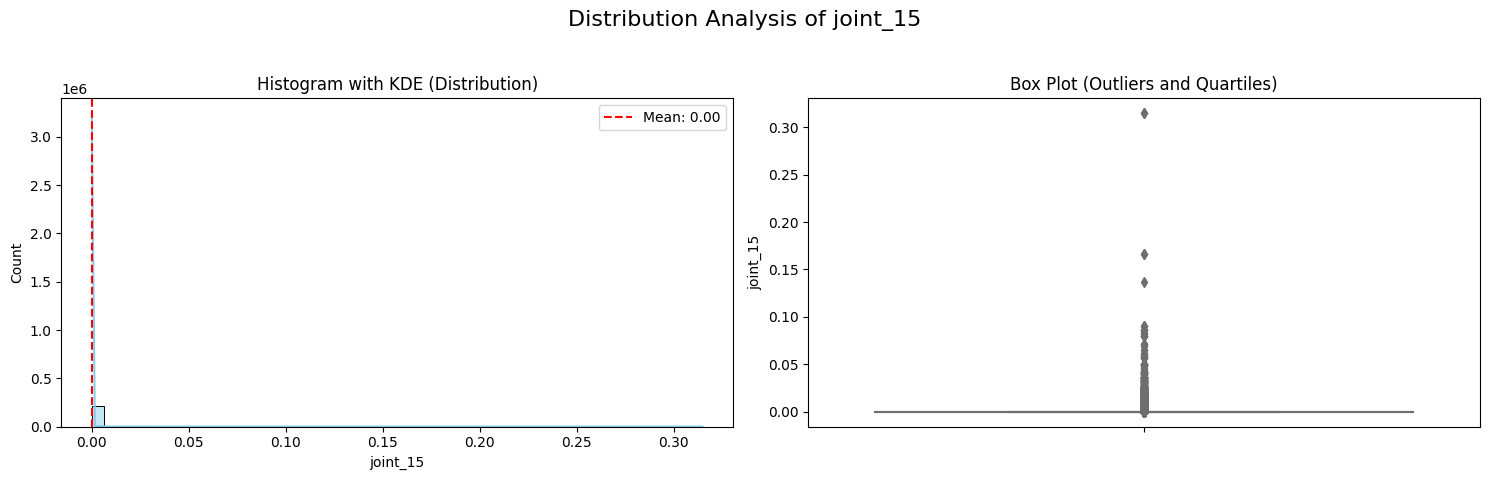


==================== FEATURE: joint_16 ====================
- Unique Values       : 103827.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0018
- Min Value           : 0.0000
- Max Value           : 0.3325
- Skewness            : 87.2526

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 87.25. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


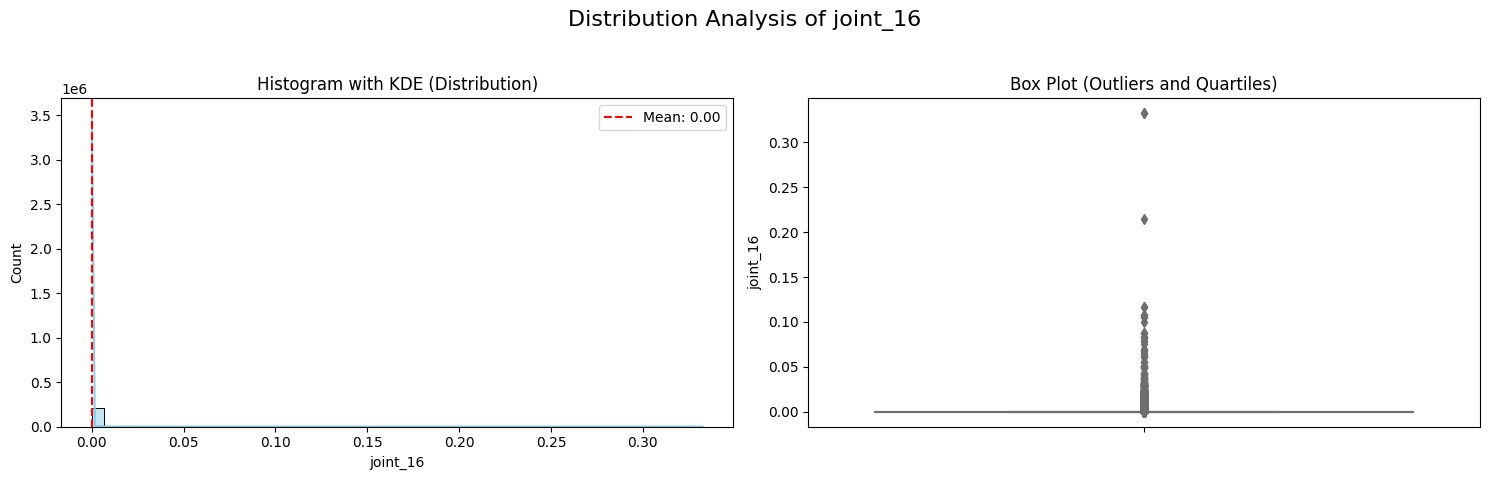


==================== FEATURE: joint_17 ====================
- Unique Values       : 110888.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0004
- Variance            : 0.0000
- Standard Deviation  : 0.0056
- Min Value           : 0.0000
- Max Value           : 0.5276
- Skewness            : 46.7297

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 46.73. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


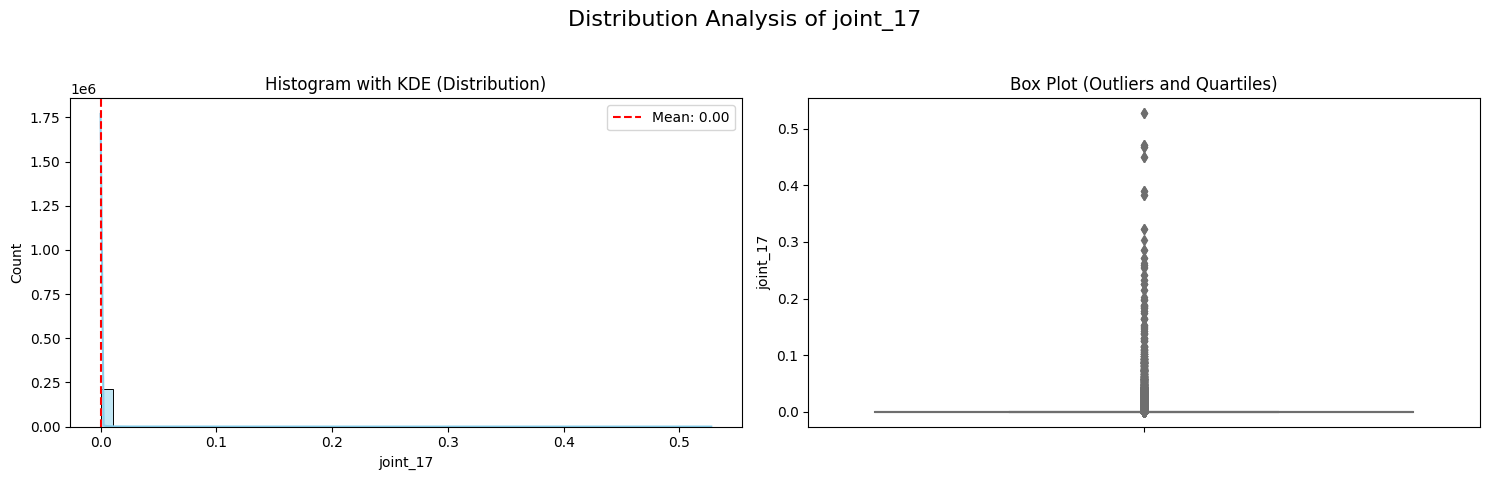


==================== FEATURE: joint_18 ====================
- Unique Values       : 100164.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0003
- Variance            : 0.0000
- Standard Deviation  : 0.0055
- Min Value           : 0.0000
- Max Value           : 1.5103
- Skewness            : 125.6088

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 125.61. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


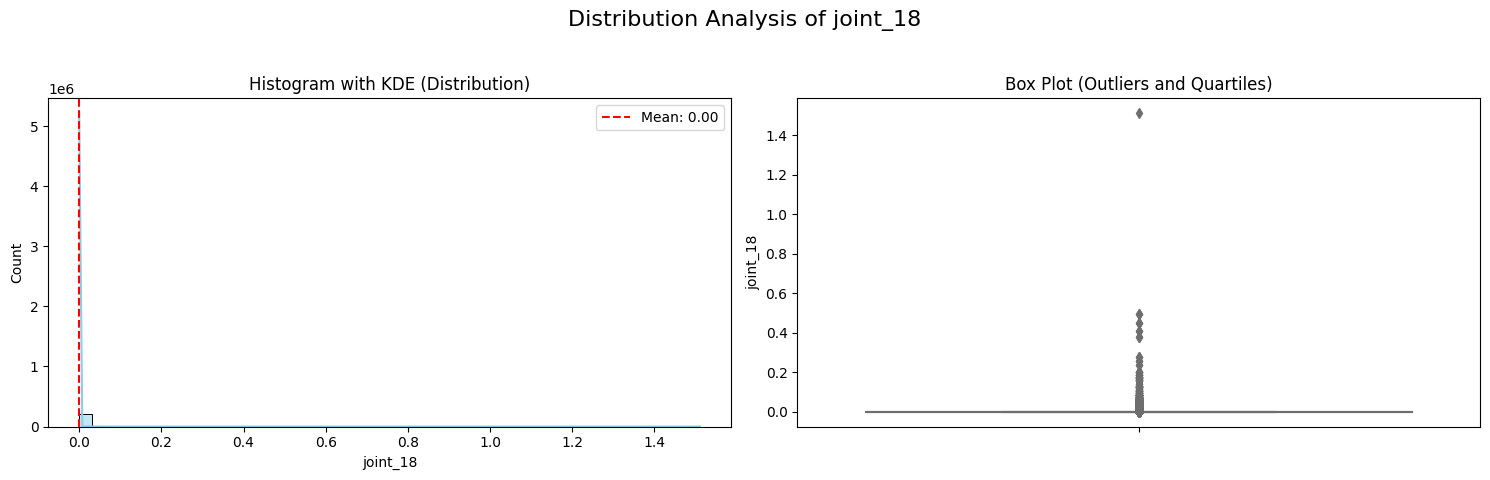


==================== FEATURE: joint_19 ====================
- Unique Values       : 117657.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0003
- Variance            : 0.0001
- Standard Deviation  : 0.0076
- Min Value           : 0.0000
- Max Value           : 1.5531
- Skewness            : 155.1370

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 155.14. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


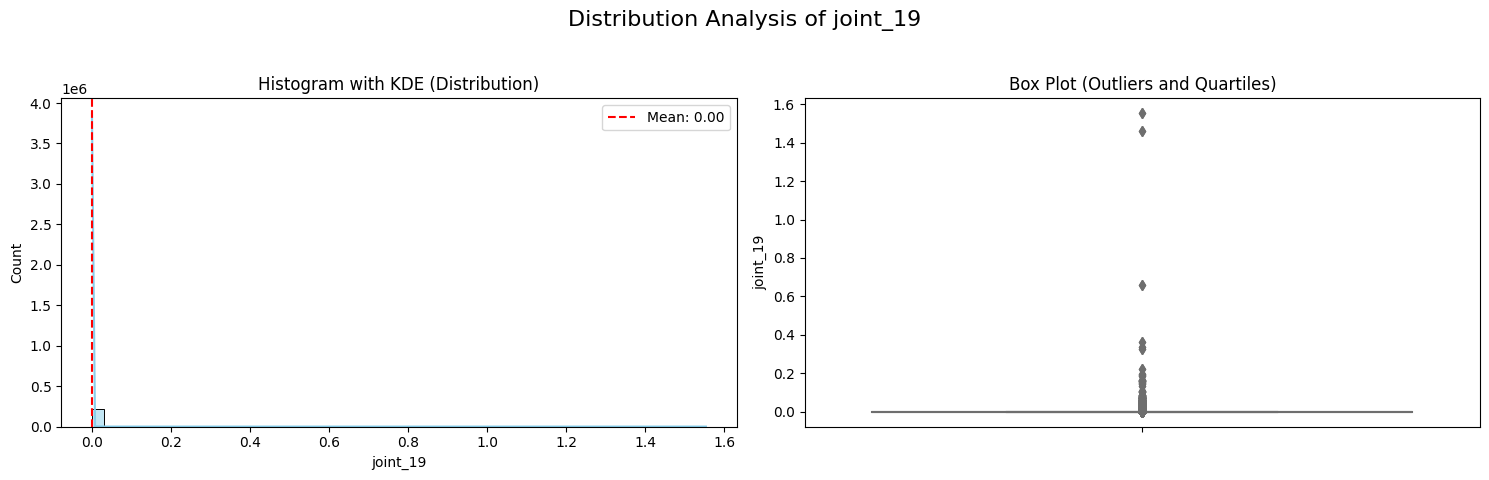


==================== FEATURE: joint_20 ====================
- Unique Values       : 128489.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0004
- Variance            : 0.0001
- Standard Deviation  : 0.0079
- Min Value           : 0.0000
- Max Value           : 1.4378
- Skewness            : 103.6156

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 103.62. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


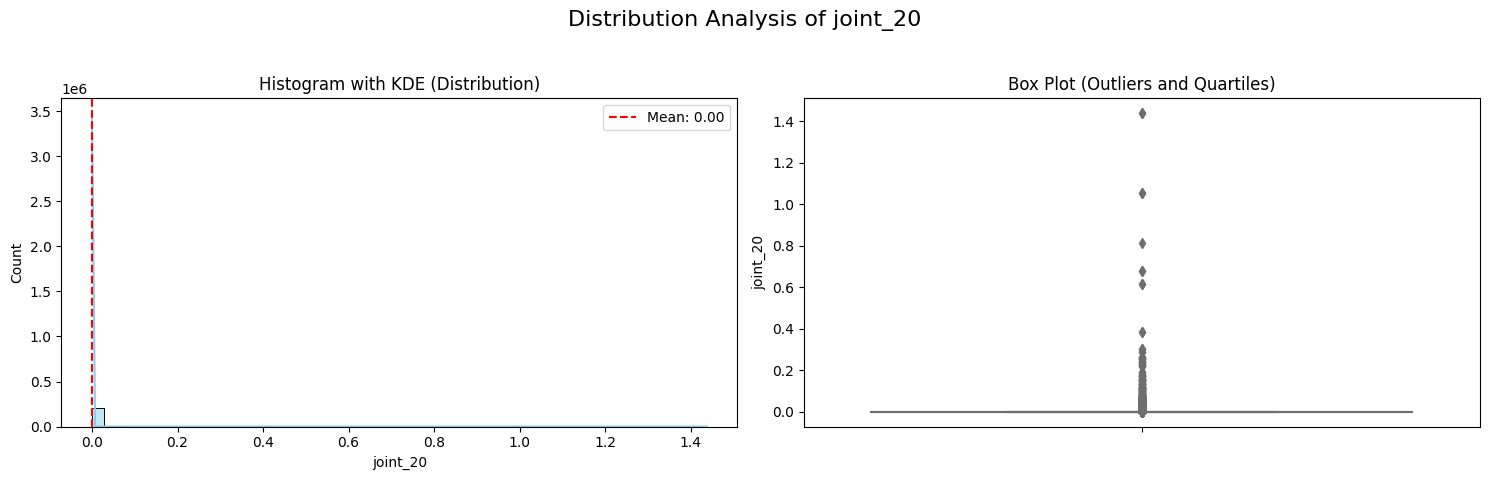


==================== FEATURE: joint_21 ====================
- Unique Values       : 137081.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0015
- Min Value           : 0.0000
- Max Value           : 0.3899
- Skewness            : 209.1407

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 209.14. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


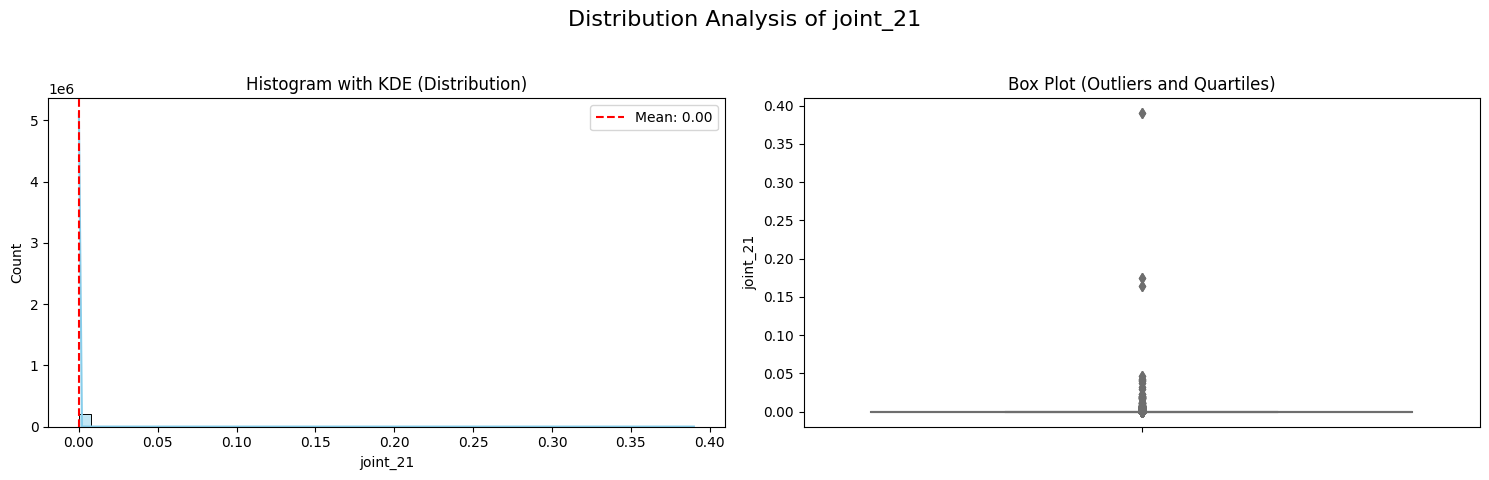


==================== FEATURE: joint_22 ====================
- Unique Values       : 135832.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0004
- Min Value           : 0.0000
- Max Value           : 0.0628
- Skewness            : 80.3536

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 80.35. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


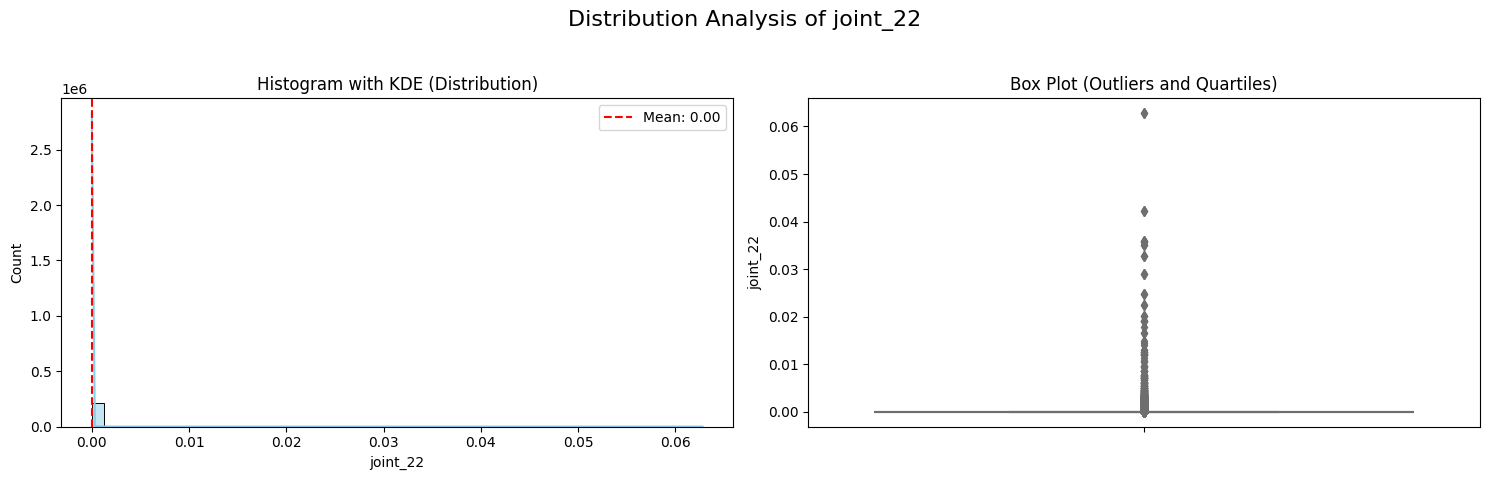


==================== FEATURE: joint_23 ====================
- Unique Values       : 120087.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0006
- Min Value           : 0.0000
- Max Value           : 0.0648
- Skewness            : 68.1678

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 68.17. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


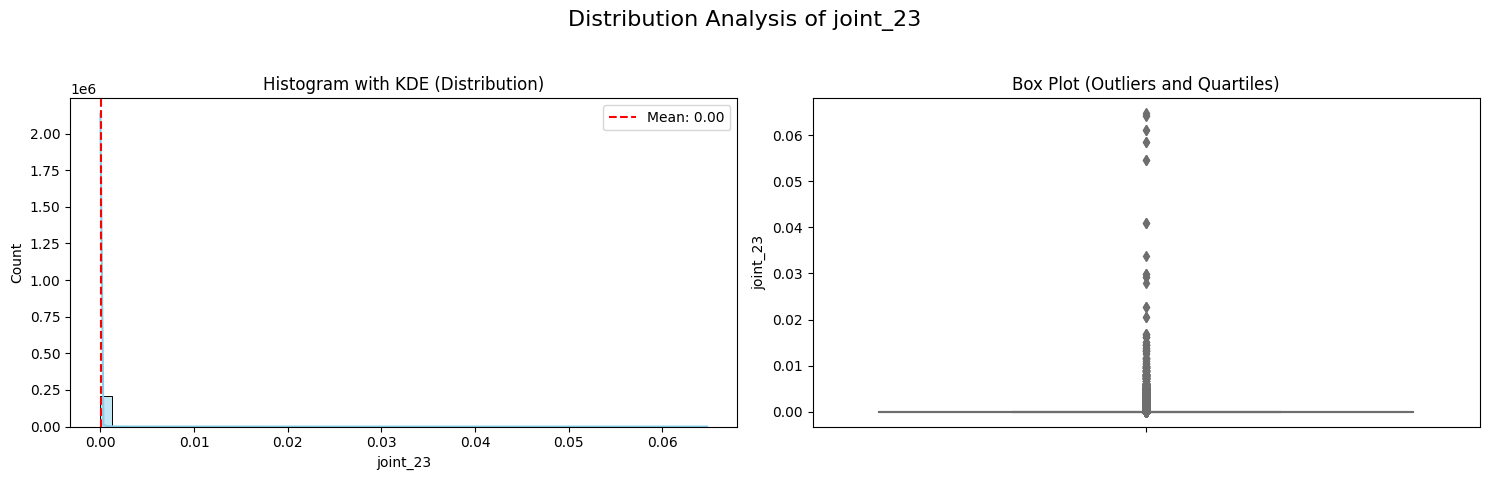


==================== FEATURE: joint_24 ====================
- Unique Values       : 116173.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0006
- Min Value           : 0.0000
- Max Value           : 0.1250
- Skewness            : 111.0916

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 111.09. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


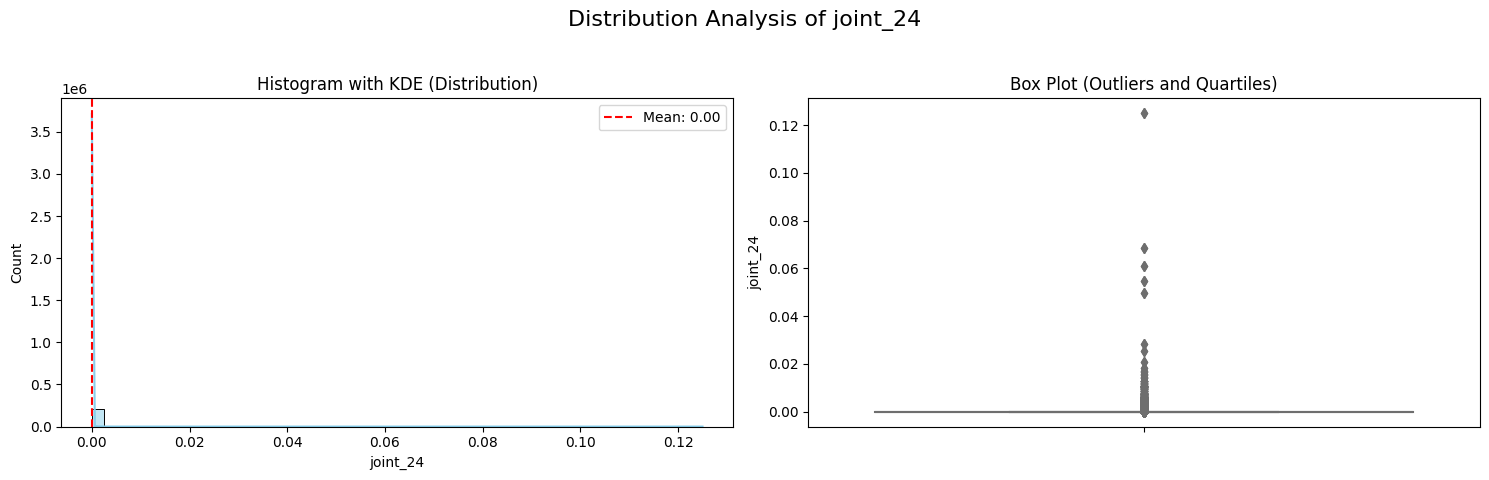


==================== FEATURE: joint_25 ====================
- Unique Values       : 117047.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0012
- Min Value           : 0.0000
- Max Value           : 0.1673
- Skewness            : 59.0266

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 59.03. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


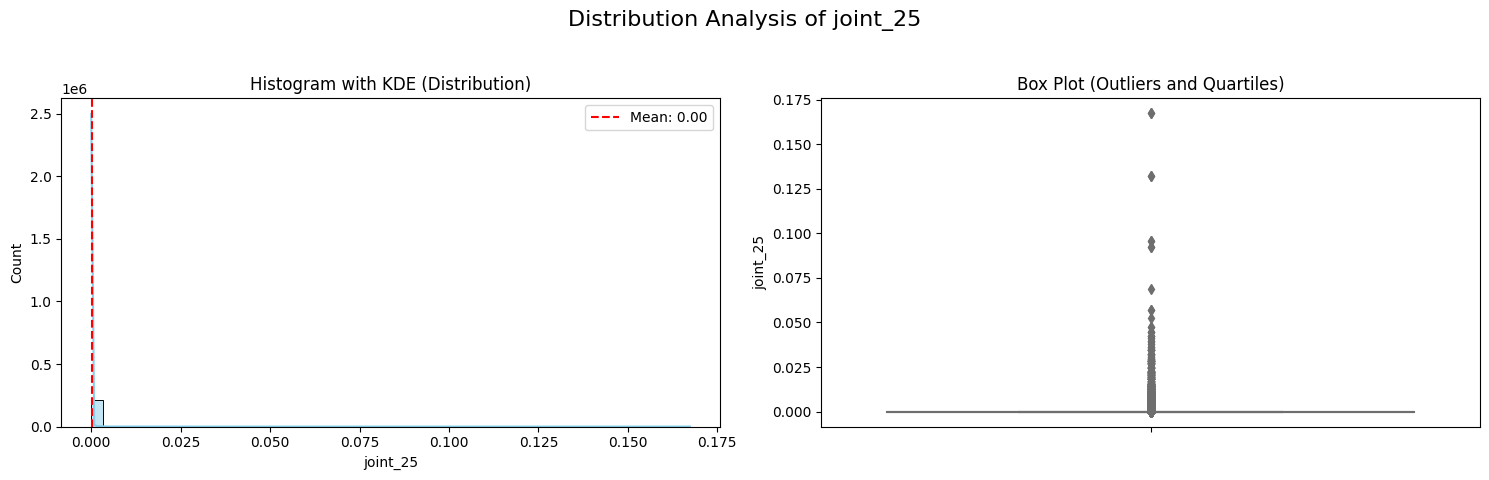


==================== FEATURE: joint_26 ====================
- Unique Values       : 206660.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0405
- Variance            : 0.0033
- Standard Deviation  : 0.0572
- Min Value           : 0.0000
- Max Value           : 1.2993
- Skewness            : 4.5553

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 4.56. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


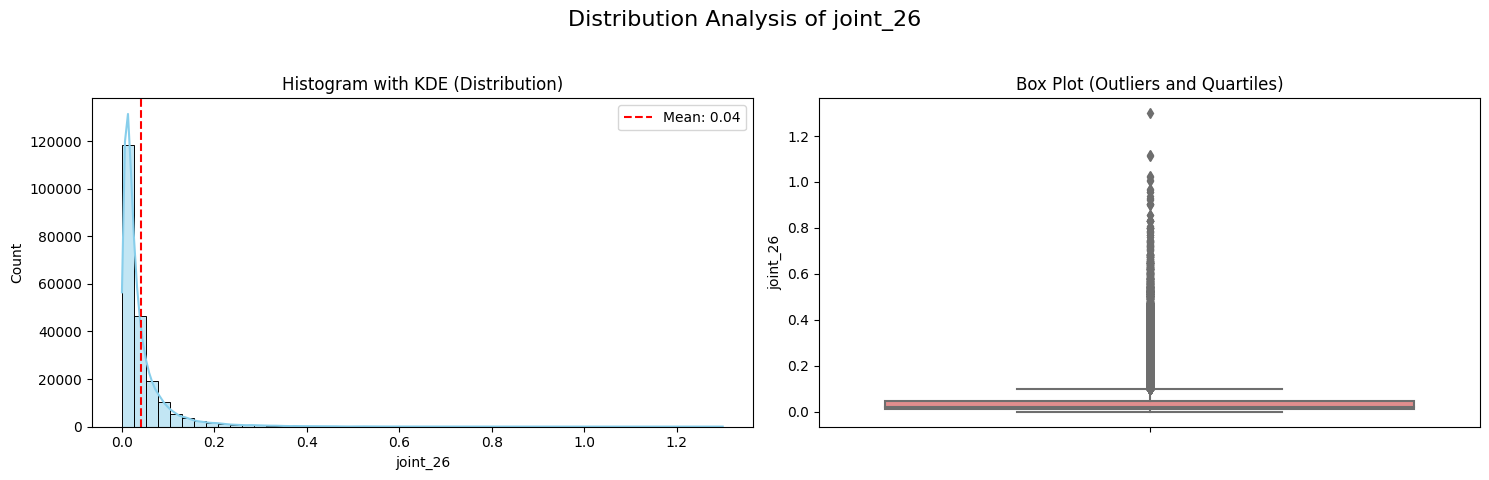


==================== FEATURE: joint_27 ====================
- Unique Values       : 205178.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0601
- Variance            : 0.0061
- Standard Deviation  : 0.0781
- Min Value           : 0.0045
- Max Value           : 1.3759
- Skewness            : 3.7669

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 3.77. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


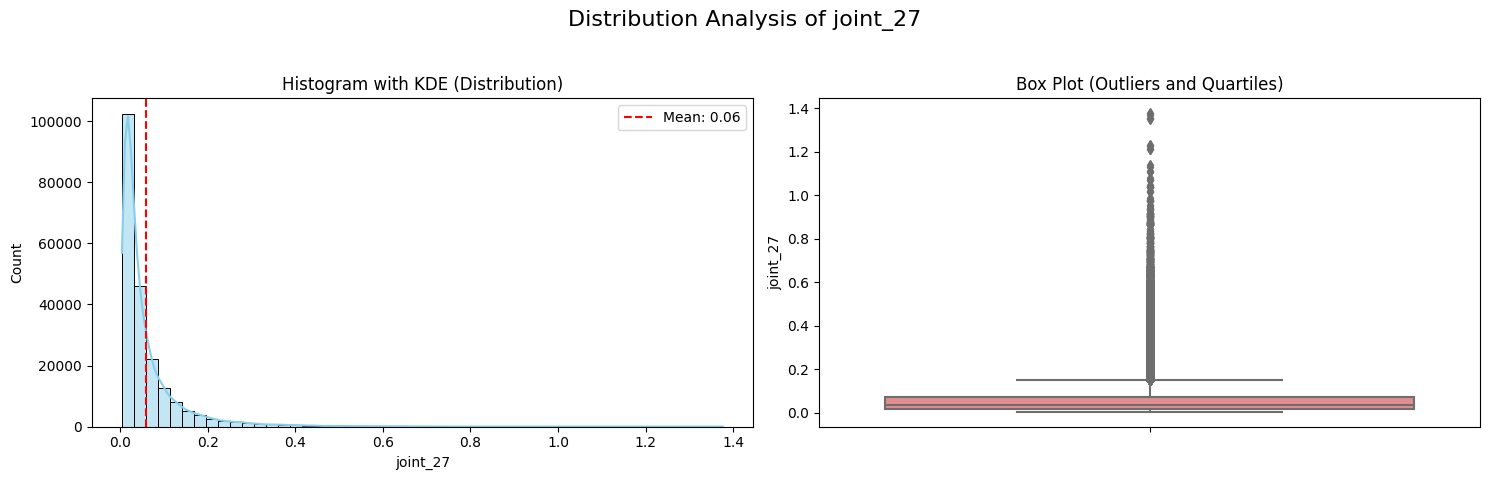


==================== FEATURE: joint_28 ====================
- Unique Values       : 209039.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0525
- Variance            : 0.0034
- Standard Deviation  : 0.0587
- Min Value           : 0.0041
- Max Value           : 1.4126
- Skewness            : 3.9958

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 4.00. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


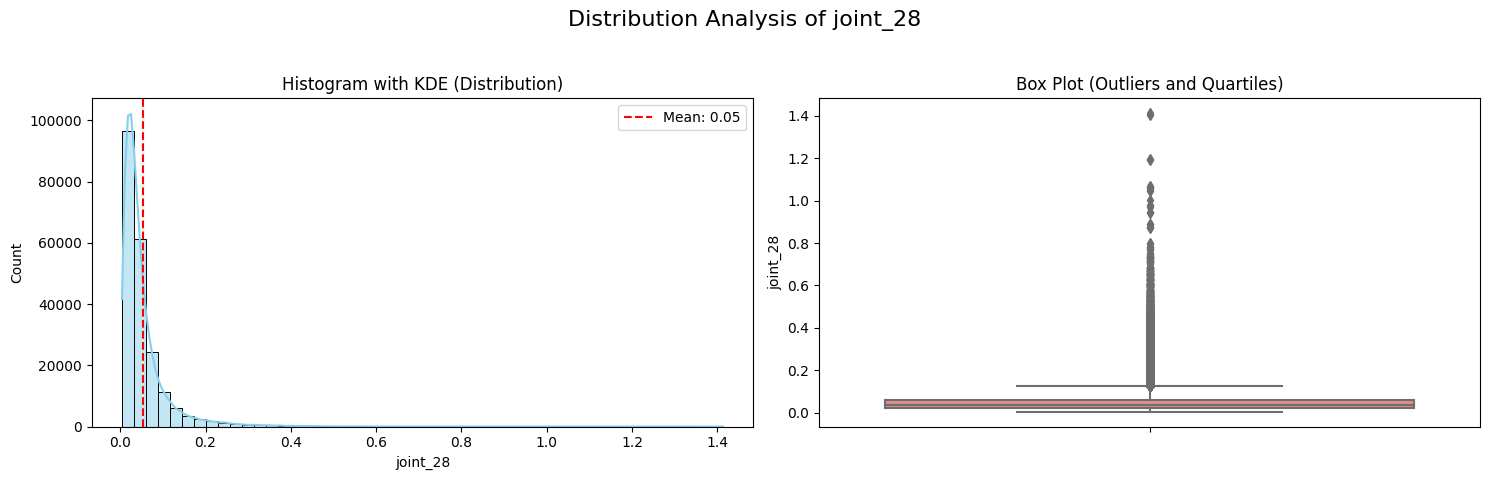


==================== FEATURE: joint_29 ====================
- Unique Values       : 210661.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0612
- Variance            : 0.0044
- Standard Deviation  : 0.0667
- Min Value           : 0.0000
- Max Value           : 1.3338
- Skewness            : 3.3622

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 3.36. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


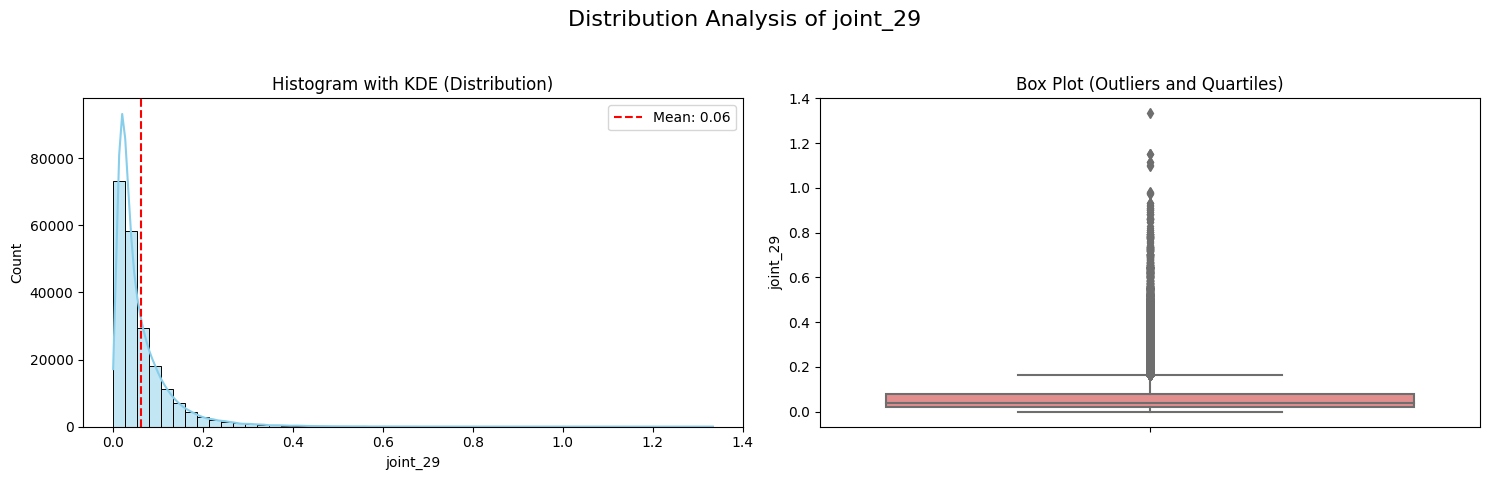

In [4]:
def analyze_continuous_features(df: pd.DataFrame, identifier_cols: List[str], cardinality_threshold: int = 20) -> None:
    """
    Analyzes and visualizes continuous features in a DataFrame.

    Args:
        df: The input DataFrame (e.g., dataset).
        identifier_cols: Columns to exclude from analysis (e.g., indices, labels).
        cardinality_threshold: Max unique values for a numerical column to be considered 
                               potentially categorical instead of continuous.
    """
    print("--- CONTINUOUS FEATURE EXPLORATORY DATA ANALYSIS (EDA) ---")
    
    # 1. Identify numerical and continuous columns
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    continuous_features = []
    for col in numerical_cols:
        if col in identifier_cols:
            continue
        # Check if the column has high cardinality to be treated as continuous
        if df[col].nunique() > cardinality_threshold:
            continuous_features.append(col)
        else:
            print(f"\n[INFO] Skipping '{col}' (N_Unique={df[col].nunique()}). Treated as low-cardinality/discrete or identifier.")

    if not continuous_features:
        print("\nNo continuous features found for analysis.")
        return

    print(f"\nAnalyzing {len(continuous_features)} Continuous Features: {continuous_features}\n")

    # 2. Loop through and analyze each feature
    for feature in continuous_features:
        print(f"\n==================== FEATURE: {feature} ====================")
        
        # --- Descriptive Statistics ---
        stats = {
            "Unique Values": df[feature].nunique(),
            "Non-Null Count": df[feature].count(),
            "Mean": df[feature].mean(),
            "Variance": df[feature].var(),
            "Standard Deviation": df[feature].std(),
            "Min Value": df[feature].min(),
            "Max Value": df[feature].max(),
            "Skewness": df[feature].skew()
        }
        
        # Print Statistics
        for key, value in stats.items():
            print(f"- {key:<20}: {value:.4f}")

        # --- Usefulness Analysis ---
        print("\n[Usefulness Analysis]")
        
        # A. Check for constant/near-constant features (low variance)
        if stats["Variance"] < 1e-3 and stats["Unique Values"] < len(df) * 0.01:
            print(f"  -> LOW USEFULNESS: Variance ({stats['Variance']:.2e}) is extremely low. This feature is nearly constant across the dataset and likely carries almost no predictive power. Consider dropping it.")
        
        # B. Check for heavy skewness (potential data transformations)
        elif abs(stats["Skewness"]) > 1.0:
            print(f"  -> HIGH SKEWNESS: Skewness is {stats['Skewness']:.2f}. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.")
        
        # C. General assessment
        else:
            print(f"  -> MEDIUM/HIGH USEFULNESS: Good variance ({stats['Variance']:.2f}) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.")
            
        
        # --- Visualization ---
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Distribution Analysis of {feature}', fontsize=16)

        sns.histplot(df[feature], kde=True, ax=axes[0], color='skyblue', bins=50)
        axes[0].set_title('Histogram with KDE (Distribution)')
        axes[0].set_xlabel(feature)
        axes[0].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {stats["Mean"]:.2f}')
        axes[0].legend()

        # Box Plot (Outliers and Quartiles)
        sns.boxplot(y=df[feature], ax=axes[1], color='lightcoral')
        axes[1].set_title('Box Plot (Outliers and Quartiles)')
        axes[1].set_ylabel(feature)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
        plt.show()

identifier_cols_to_exclude = ['sample_index', 'label']

analyze_continuous_features(dataset, identifier_cols=identifier_cols_to_exclude, cardinality_threshold=5)

In [6]:
columns = dataset.columns
dataset[columns].describe()

,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
count,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,...,211840.000000,211840.000000,211840.000000,2.118400e+05,2.118400e+05,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000
mean,661.500000,79.500000,0.984106,1.002312,0.833719,0.839993,0.727537,0.770178,0.890958,0.888862,...,0.000374,0.000032,0.000024,4.138805e-05,3.408469e-05,0.000107,0.040524,0.060134,0.052490,0.061218
std,382.206671,46.187228,0.204744,0.191175,0.298458,0.298573,0.416147,0.402997,0.234902,0.235090,...,0.007861,0.001464,0.000413,5.570593e-04,6.285418e-04,0.001203,0.057234,0.078081,0.058698,0.066651
min,0.000000,0.000000,0.000000,0.036813,0.014754,0.047624,0.000000,0.001314,0.000000,0.000000,...,0.000009,0.000002,0.000001,0.000000e+00,0.000000e+00,0.000000,0.000000,0.004475,0.004083,0.000000
25%,330.750000,39.750000,0.867980,0.897176,0.625202,0.604872,0.223317,0.292825,0.839565,0.826372,...,0.000026,0.000003,0.000003,4.412668e-07,2.325231e-07,0.000000,0.010886,0.017376,0.020317,0.021007
50%,661.500000,79.500000,1.040931,1.063110,0.969119,0.979624,0.943414,0.996528,0.947562,0.957547,...,0.000032,0.000004,0.000004,2.527479e-06,2.060598e-06,0.000006,0.022146,0.033317,0.035334,0.038696
75%,992.250000,119.250000,1.128461,1.139088,1.052242,1.060542,1.055148,1.082449,1.031237,1.038240,...,0.000046,0.000006,0.000006,4.590578e-06,3.708785e-06,0.000014,0.046722,0.069825,0.061336,0.077690
max,1323.000000,159.000000,1.500341,1.499030,1.346970,1.333893,1.420582,1.420990,1.447161,1.452162,...,1.437842,0.389906,0.062781,6.476609e-02,1.249919e-01,0.167318,1.299322,1.375895,1.412636,1.333794


## Focus on the Joint between 13 and 25

In [12]:
def plot_zoomed_distributions_notebook(
    df: pd.DataFrame, 
    columns_to_plot: List[str], 
    zoom_limit: float = 0.05,
    std_multiplier: float = 3.0
):
    """
    Plots a zoomed-in histogram for a specified set of columns in a DataFrame,
    displaying the output directly in a notebook environment, with lines for 
    Mean and +/- N Standard Deviations.
    """
    
    for column_name in columns_to_plot:
        if column_name in df.columns:
            print(f"Check: Plotting {column_name}") 
            
            data = df[column_name].dropna()
            mean_val = data.mean()
            std_val = data.std()
            
            plt.figure(figsize=(10, 6))

            ax = sns.histplot(
                data=df,
                x=column_name,
                bins=50,
                kde=True,
                color='skyblue',
                edgecolor='black'
            )

            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media ({mean_val:.4f})')
            
            ax.axvline(
                mean_val + (std_multiplier * std_val), 
                color='darkorange', 
                linestyle=':', 
                linewidth=2, 
                label=f'+{std_multiplier:.1f} STD'
            )
            
            ax.axvline(
                mean_val - (std_multiplier * std_val), 
                color='darkorange', 
                linestyle=':', 
                linewidth=2, 
                label=f'-{std_multiplier:.1f} STD'
            )
            
            plt.xlim(-zoom_limit*2, zoom_limit*2)
            plt.ylim(0, 20000)
            
            plt.title(
                f'Zoomed Distribution of {column_name} (Media e ±{std_multiplier:.1f} Dev. Standard)',
                fontsize=16
            )
            plt.xlabel(f'{column_name} Value', fontsize=14)
            plt.ylabel('Count / Density', fontsize=14)
            plt.grid(axis='y', alpha=0.5)
            
            plt.legend() 
            
            plt.show() 
            
        else:
            print(f"Warning: Column '{column_name}' not found in the DataFrame. Skipping.")

Check: Plotting joint_13


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


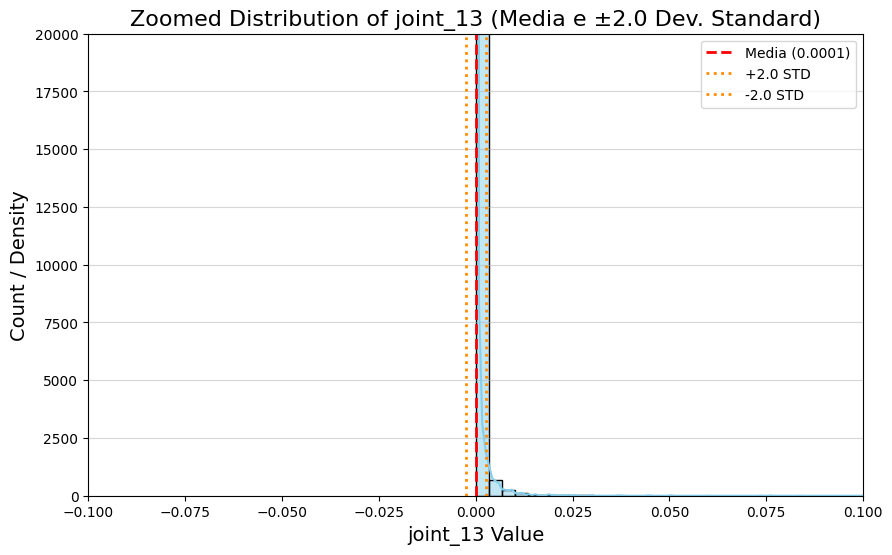

Check: Plotting joint_14


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


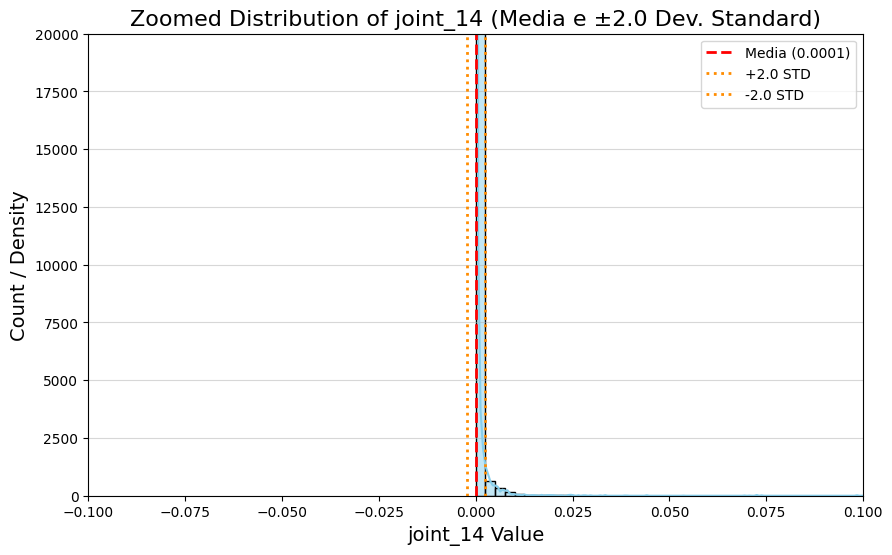

Check: Plotting joint_15


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


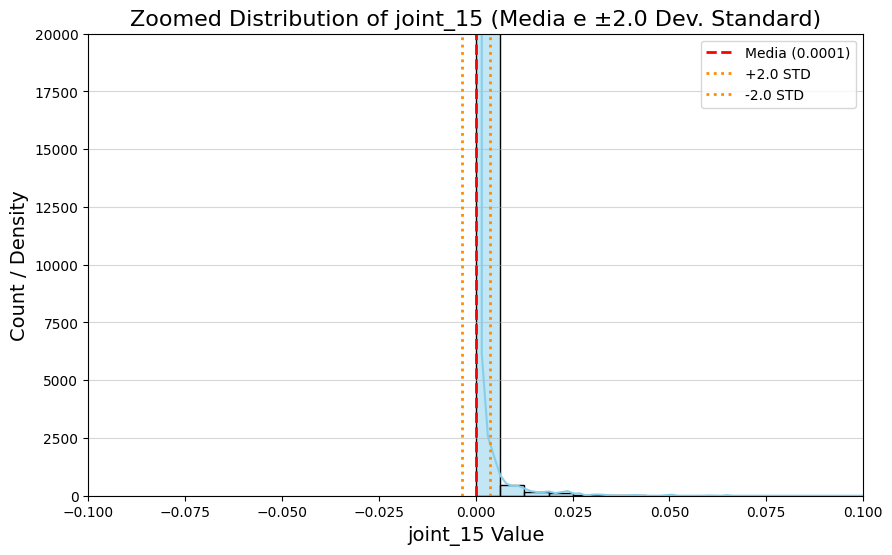

Check: Plotting joint_16


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


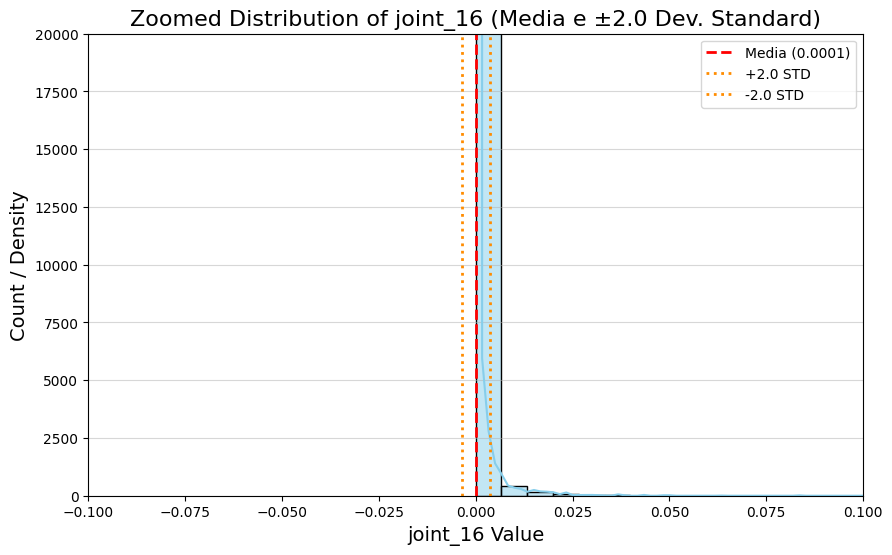

Check: Plotting joint_17


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


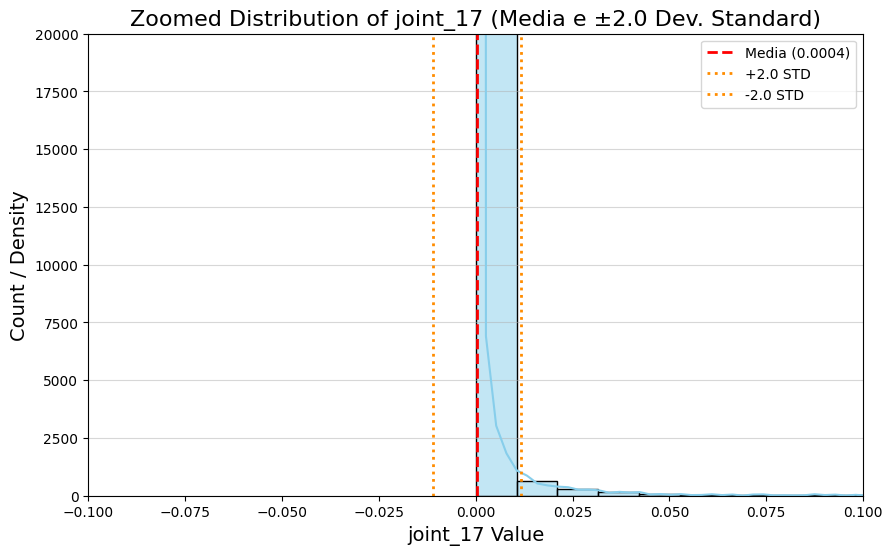

Check: Plotting joint_18


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


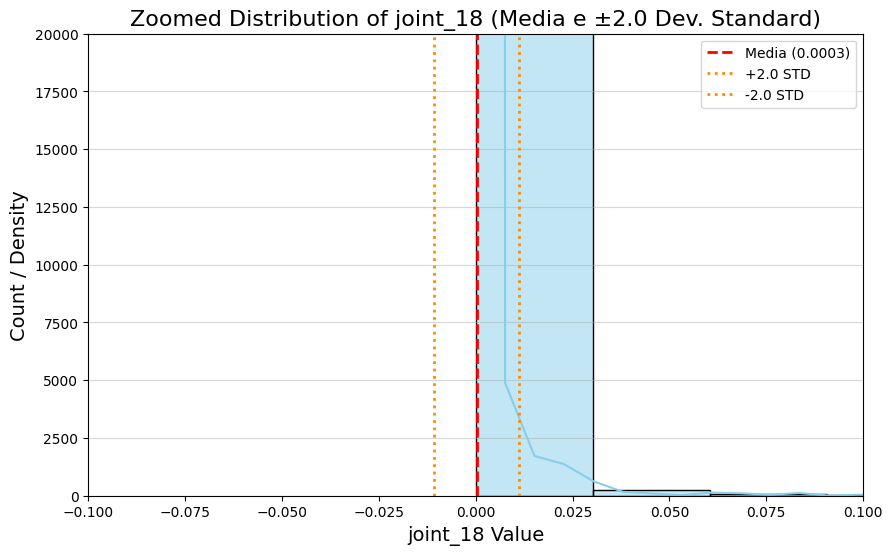

Check: Plotting joint_19


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


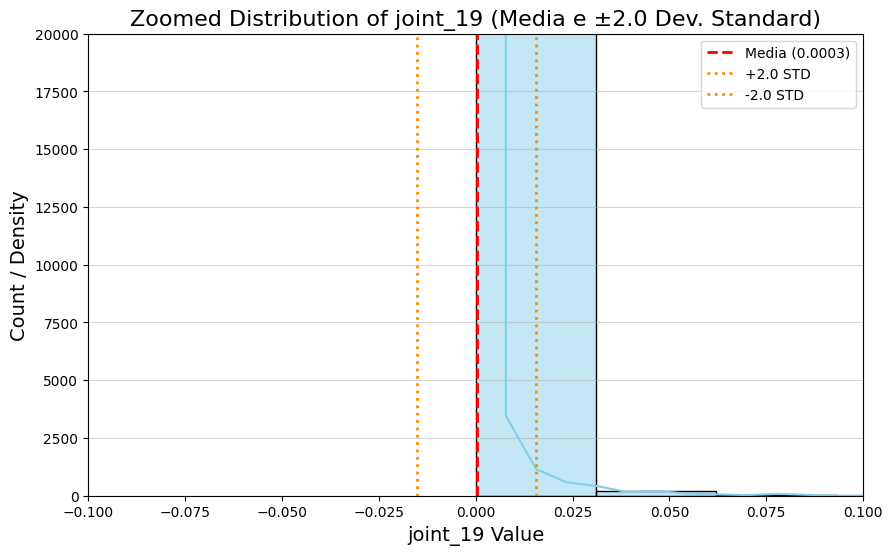

Check: Plotting joint_20


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


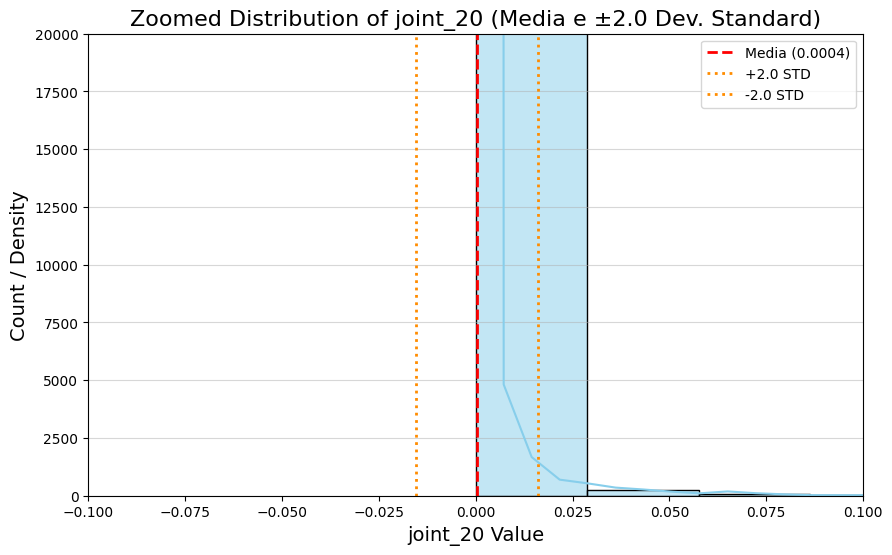

Check: Plotting joint_21


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


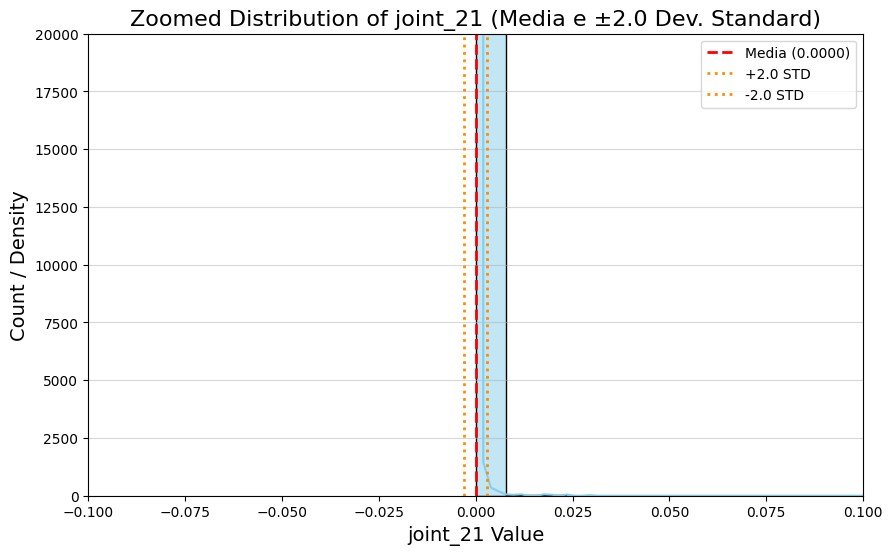

Check: Plotting joint_22


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


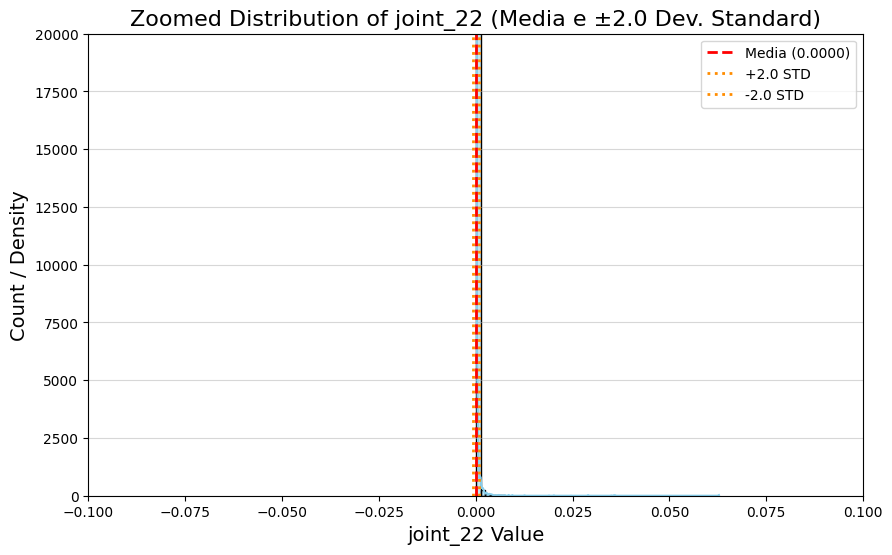

Check: Plotting joint_23


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


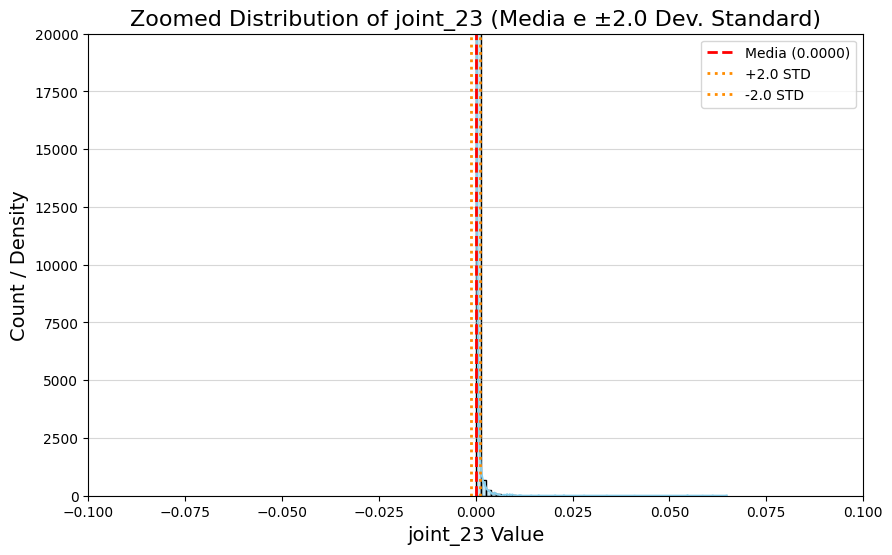

Check: Plotting joint_24


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


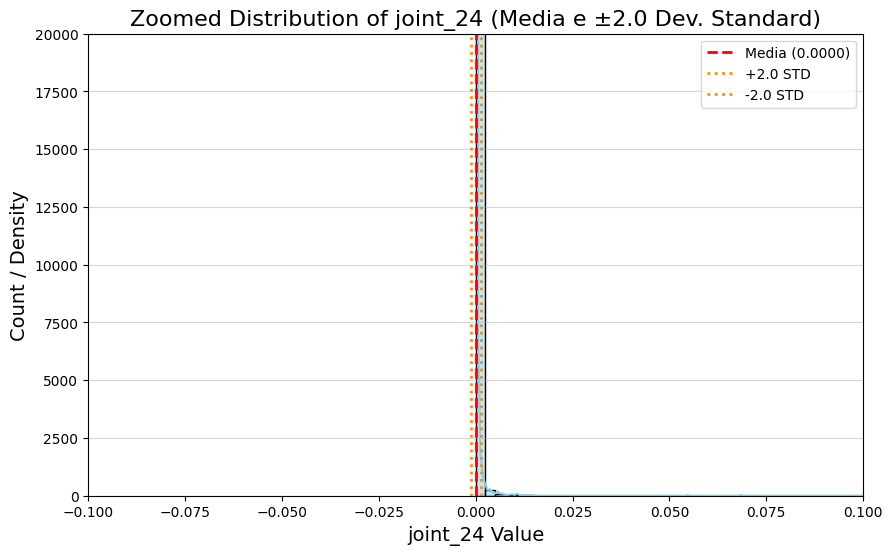

Check: Plotting joint_25


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


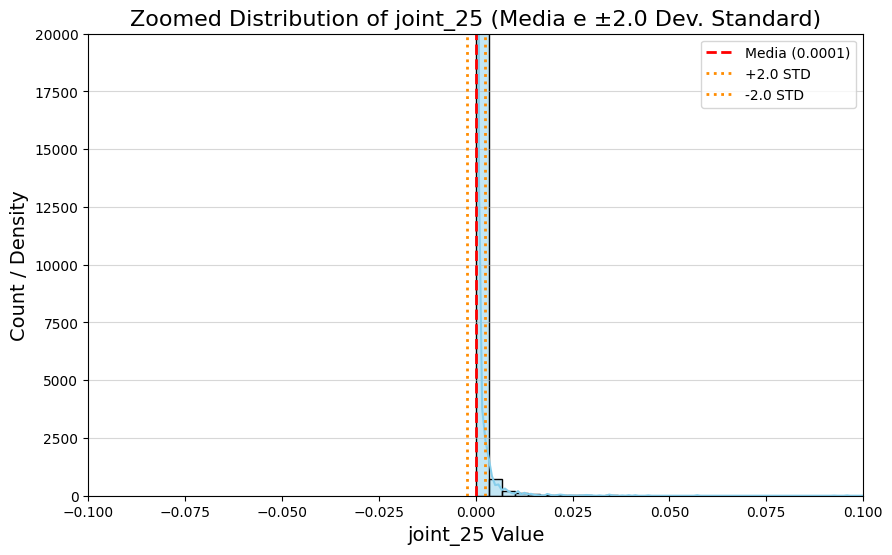

In [13]:
columns = ['joint_13', 'joint_14', 'joint_15',
       'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21',
       'joint_22', 'joint_23', 'joint_24', 'joint_25']

plot_zoomed_distributions_notebook(dataset, columns, std_multiplier=2.0)

## Visualization of the forecasting of the Dataset!

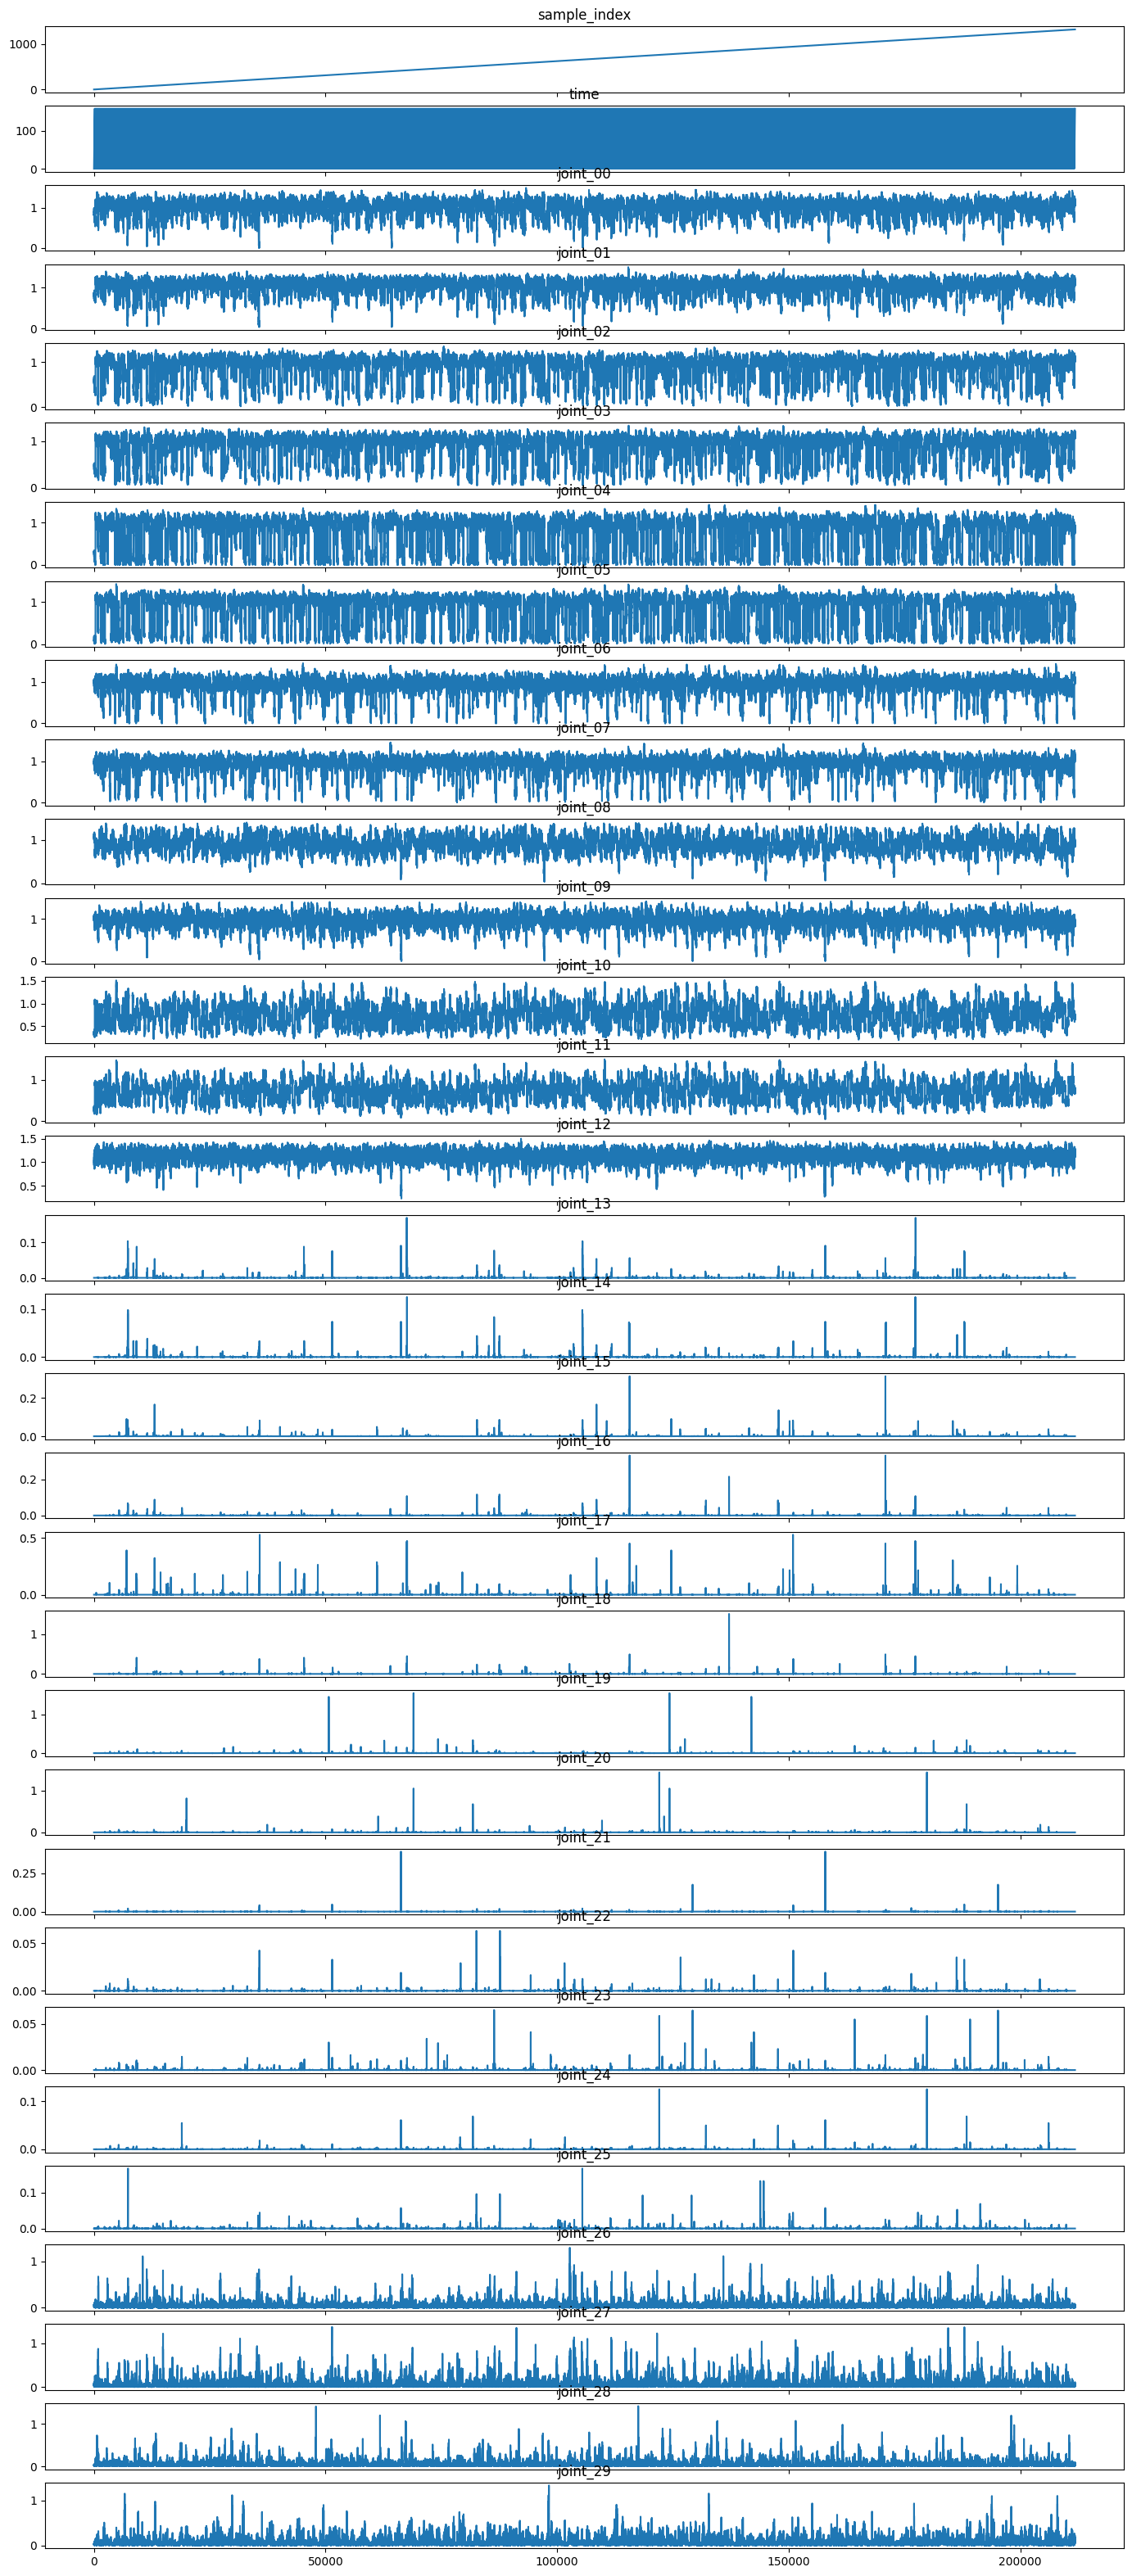

In [15]:
# Define a function to plot and inspect specified columns of a dataframe
def inspect_dataframe(df, columns):
    # Create subplots for each column
    figs, axs = plt.subplots(len(columns), 1, sharex=True, figsize=(17, 40))

    # Iterate through the specified columns and plot each
    for i, col in enumerate(columns):
        axs[i].plot(df[col])
        axs[i].set_title(col)

    # Display the plots
    plt.show()

# Call the function to inspect all columns of the dataset
inspect_dataframe(dataset, dataset.columns)

#### Binary Spiking Feature

Implementation Binary Spiking Feature creation. It uses the $3\sigma$ rule (Mean + 3 Standard Deviations) to define the threshold, which is a common way to capture events that are statistically rare.

The difficult part is to determinate when to cut the signals!

In [78]:
def analyze_sigma_spike_detection(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    results = {}
    total_count = len(df)
    
    # Moltiplicatori STD da confrontare
    multipliers = [2.0, 3.0]
    
    for column_name in columns:
        if column_name not in df.columns:
            print(f"Warning: Colonna '{column_name}' non trovata. Saltata.")
            continue
            
        data = df[column_name].dropna()
        if data.empty:
            print(f"Warning: Colonna '{column_name}' vuota. Saltata.")
            continue

        mean_val = data.mean()
        std_val = data.std()
        
        results[column_name] = {}
        
        for n in multipliers:
            # Calcola la soglia superiore: Media + N * STD
            threshold = mean_val + (n * std_val)
            
            # Conta le osservazioni che superano la soglia (spike)
            spike_count = df[df[column_name] > threshold].shape[0]
            
            # Calcola la percentuale
            spike_percent = (spike_count / total_count) * 100
            
            # Memorizza i risultati
            results[column_name][f'{n:.1f}-Sigma Count'] = spike_count
            results[column_name][f'{n:.1f}-Sigma %'] = f'{spike_percent:.4f}%'
            results[column_name][f'{n:.1f}-Sigma Threshold'] = f'{threshold:.6f}'
        
    # Converte i risultati in un DataFrame per una visualizzazione chiara
    summary_df = pd.DataFrame.from_dict(results, orient='index')
    return summary_df

In [74]:
def binary_spike_feature_mean_std(df: pd.DataFrame, columns: List[str], std_multiplier: float = 3.0) -> pd.DataFrame:

    
    for column_name in columns:
        if column_name not in df.columns:
            print(f"Warning: Column '{column_name}' not found in the DataFrame. Skipping.")
            continue
        
        data = df[column_name].dropna()
        
        if data.empty:
            print(f"Warning: Column '{column_name}' is empty after dropping NaN values. Skipping.")
            continue

        mean_val = data.mean()
        std_val = data.std()
        threshold = mean_val + (std_multiplier * std_val)
        
        print(f"Colonna '{column_name}': Soglia ({std_multiplier}*STD) = {threshold:.6f}")
        
        df[column_name] = np.where(df[column_name] > threshold, 1, 0)
        
        total_spikes = df[column_name].sum()
        print(f"Colonna '{column_name}' sovrascritta. Totale spike (valore 1) trovati: {total_spikes}")
        
    return df


In [82]:
binary_spike_feature_mean_std(
    df=dataset, 
    columns=columns,
    std_multiplier = 2.0
)

Colonna 'joint_13': Soglia (2.0*STD) = 0.002619
Colonna 'joint_13' sovrascritta. Totale spike (valore 1) trovati: 1556
Colonna 'joint_14': Soglia (2.0*STD) = 0.002329
Colonna 'joint_14' sovrascritta. Totale spike (valore 1) trovati: 1452
Colonna 'joint_15': Soglia (2.0*STD) = 0.003785
Colonna 'joint_15' sovrascritta. Totale spike (valore 1) trovati: 1449
Colonna 'joint_16': Soglia (2.0*STD) = 0.003678
Colonna 'joint_16' sovrascritta. Totale spike (valore 1) trovati: 1408
Colonna 'joint_17': Soglia (2.0*STD) = 0.011657
Colonna 'joint_17' sovrascritta. Totale spike (valore 1) trovati: 1299
Colonna 'joint_18': Soglia (2.0*STD) = 0.011308
Colonna 'joint_18' sovrascritta. Totale spike (valore 1) trovati: 1186
Colonna 'joint_19': Soglia (2.0*STD) = 0.015557
Colonna 'joint_19' sovrascritta. Totale spike (valore 1) trovati: 619
Colonna 'joint_20': Soglia (2.0*STD) = 0.016096
Colonna 'joint_20' sovrascritta. Totale spike (valore 1) trovati: 826
Colonna 'joint_21': Soglia (2.0*STD) = 0.002960
Co

,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,0.842535,0.845934,0.573001,0.395143,0.302871,0.157435,0.977430,0.950154,...,0,0,0,0,0,0,0.019372,0.066324,0.022228,0.013576
1,0,1,0.898836,0.814810,0.629339,0.469420,0.247027,0.144169,1.005981,0.993922,...,0,0,0,0,0,0,0.069747,0.080417,0.023650,0.038793
2,0,2,0.957765,0.890690,0.608661,0.444819,0.295657,0.113608,0.989857,0.982370,...,0,0,0,0,0,0,0.054968,0.058811,0.027023,0.054202
3,0,3,0.832596,0.751427,0.605583,0.504279,0.236913,0.145222,1.001372,0.944723,...,0,0,0,0,0,0,0.048695,0.047128,0.016151,0.024983
4,0,4,0.805971,0.810004,0.565170,0.514796,0.269761,0.069992,1.023796,0.948609,...,0,0,0,0,0,0,0.019762,0.031116,0.015618,0.017931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211835,1323,155,1.120441,1.083688,1.063497,1.215581,0.831757,0.813162,1.004327,1.084559,...,0,0,0,0,0,0,0.012699,0.047120,0.012946,0.093722
211836,1323,156,1.068530,1.213960,1.012800,1.114519,0.832875,0.867879,0.952825,1.076518,...,0,0,0,0,0,0,0.035094,0.071830,0.045175,0.091877
211837,1323,157,1.167755,1.100908,1.047883,1.130221,0.838667,0.830906,1.066915,1.107702,...,0,0,0,0,0,0,0.033666,0.062249,0.020945,0.105759
211838,1323,158,1.110743,1.161241,1.012890,1.146956,0.805712,0.865316,1.007186,1.007949,...,0,0,0,0,0,0,0.068592,0.031173,0.026611,0.142396


In [83]:
dataset.describe()

,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
count,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,...,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000
mean,661.500000,79.500000,0.984106,1.002312,0.833719,0.839993,0.727537,0.770178,0.890958,0.888862,...,0.003899,0.000845,0.003432,0.006656,0.004319,0.007926,0.040524,0.060134,0.052490,0.061218
std,382.206671,46.187228,0.204744,0.191175,0.298458,0.298573,0.416147,0.402997,0.234902,0.235090,...,0.062322,0.029056,0.058481,0.081312,0.065579,0.088674,0.057234,0.078081,0.058698,0.066651
min,0.000000,0.000000,0.000000,0.036813,0.014754,0.047624,0.000000,0.001314,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004475,0.004083,0.000000
25%,330.750000,39.750000,0.867980,0.897176,0.625202,0.604872,0.223317,0.292825,0.839565,0.826372,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010886,0.017376,0.020317,0.021007
50%,661.500000,79.500000,1.040931,1.063110,0.969119,0.979624,0.943414,0.996528,0.947562,0.957547,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022146,0.033317,0.035334,0.038696
75%,992.250000,119.250000,1.128461,1.139088,1.052242,1.060542,1.055148,1.082449,1.031237,1.038240,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046722,0.069825,0.061336,0.077690
max,1323.000000,159.000000,1.500341,1.499030,1.346970,1.333893,1.420582,1.420990,1.447161,1.452162,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.299322,1.375895,1.412636,1.333794


In [87]:
dataset.columns
columns = ['joint_00', 'joint_01', 'joint_02', 'joint_03',
       'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09',
       'joint_10', 'joint_11', 'joint_12','joint_26', 'joint_27',
       'joint_28', 'joint_29' ]

In [88]:
scaler = MinMaxScaler()
dataset[columns] = scaler.fit_transform(dataset[columns])

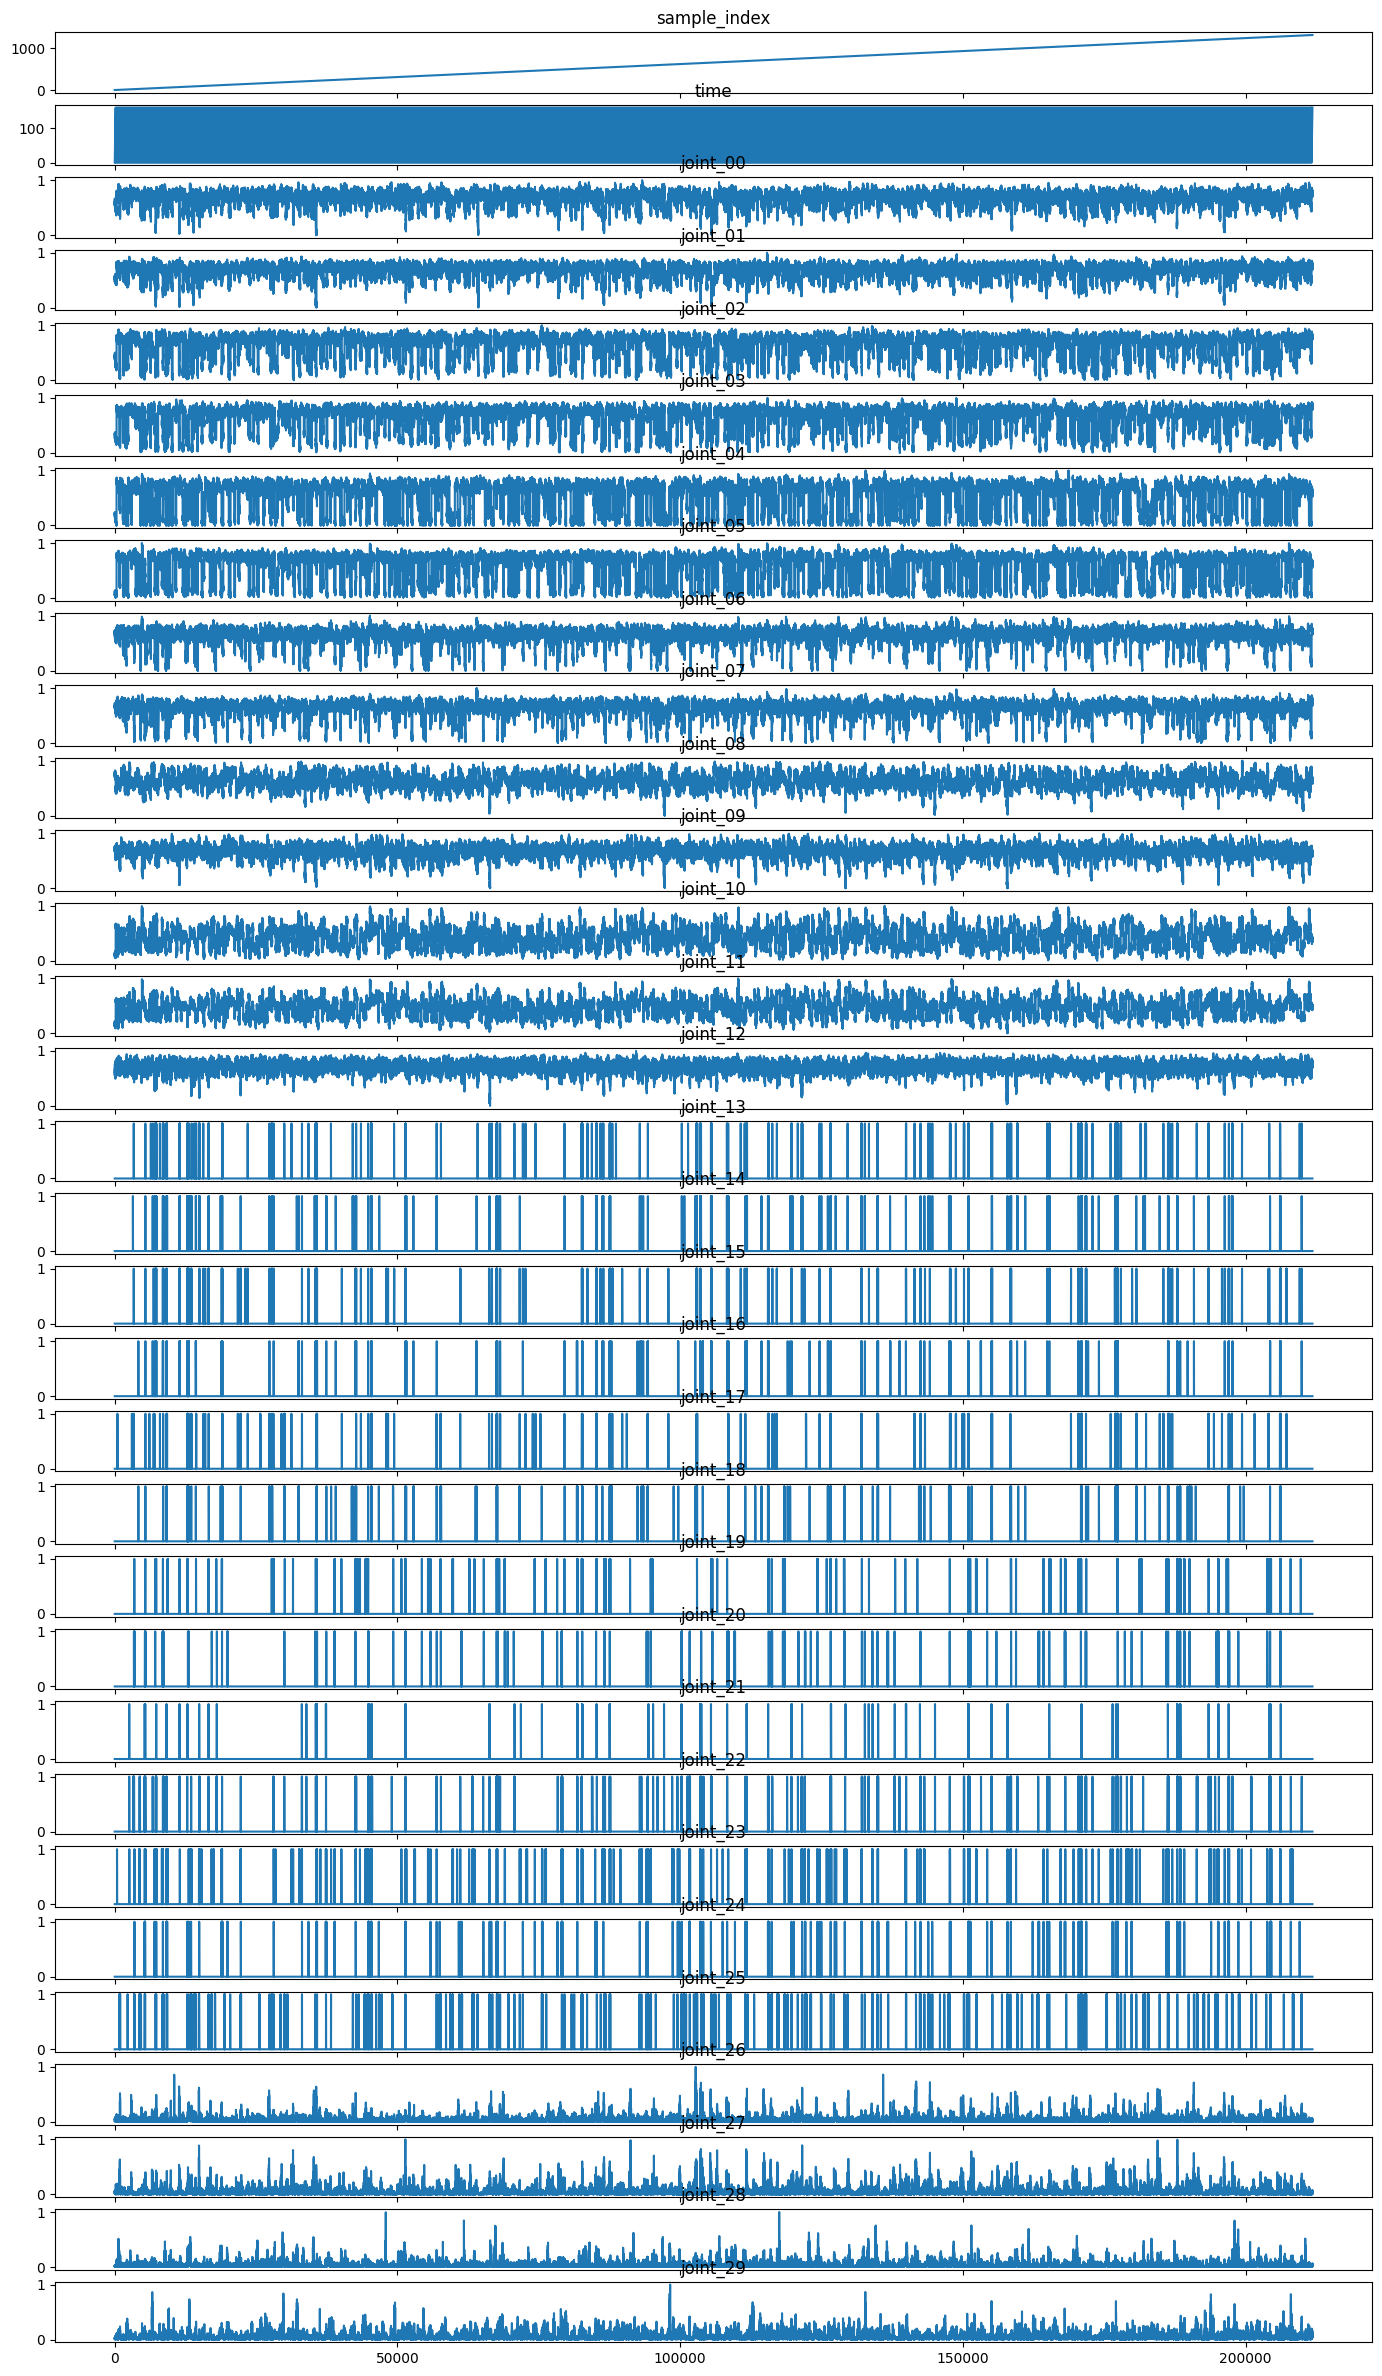

In [89]:
def inspect_dataframe(df, columns):
    # Create subplots for each column
    figs, axs = plt.subplots(len(columns), 1, sharex=True, figsize=(17, 30))

    # Iterate through the specified columns and plot each
    for i, col in enumerate(columns):
        axs[i].plot(df[col])
        axs[i].set_title(col)

    # Display the plots
    plt.show()

inspect_dataframe(dataset, dataset.columns)

In [91]:
dataset.describe()

,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
count,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,...,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000
mean,661.500000,79.500000,0.655922,0.660298,0.614739,0.616021,0.512140,0.541577,0.615659,0.612096,...,0.003899,0.000845,0.003432,0.006656,0.004319,0.007926,0.031188,0.040584,0.034366,0.045898
std,382.206671,46.187228,0.136465,0.130743,0.224031,0.232123,0.292941,0.283865,0.162319,0.161889,...,0.062322,0.029056,0.058481,0.081312,0.065579,0.088674,0.044049,0.056934,0.041673,0.049971
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,330.750000,39.750000,0.578522,0.588396,0.458220,0.433228,0.157201,0.205336,0.580146,0.569063,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008378,0.009407,0.011526,0.015750
50%,661.500000,79.500000,0.693796,0.701877,0.716374,0.724576,0.664104,0.701015,0.654773,0.659394,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017045,0.021031,0.022187,0.029012
75%,992.250000,119.250000,0.752137,0.753838,0.778769,0.787485,0.742758,0.761536,0.712593,0.714961,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035959,0.047651,0.040647,0.058247
max,1323.000000,159.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
